In [4]:
import os
import sys
os.chdir('/work/shannon/fine-tune_plm')
# sys.path.insert(0, os.getcwd())

import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
from confit.metrics.correlation import spearman
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [6]:
fixed = pd.read_csv("performance_summary_spearman_fixed.csv", index_col=0)

In [7]:
fixed.describe()

,shot,a_init,spearman,zeroshot_sr,num_mutations
count,2896.0,2896.000000,2896.000000,2871.000000,2896.000000
mean,96.0,-0.427590,0.485725,0.432367,945.261050
std,0.0,0.549638,0.167897,0.184334,829.053775
min,96.0,-1.000000,-0.093170,-0.064227,36.000000
25%,96.0,-1.000000,0.380754,0.331102,318.000000
50%,96.0,0.100000,0.517441,0.459064,672.000000
75%,96.0,0.100000,0.607260,0.566665,1398.000000
max,96.0,0.100000,0.808056,0.735572,3384.000000


In [ ]:
import itertools
from Bio import SeqIO

In [ ]:
pd.read_csv("/work/yunan/PsiFit/data/proteingym/IF1_ECOLI_Kelsic_2016/proteingym_dms.tsv", sep='\t')

,mutant,DMS_score
0,M1H,0.147500
1,M1G,-0.001750
2,M1I,0.118000
3,M1L,0.080333
4,M1N,0.407500
...,...,...
1362,R72S,0.923333
1363,R72T,0.911000
1364,R72V,0.904750
1365,R72D,0.853500


In [ ]:
import sys
sys.path.insert(0, "/work/shannon/fine-tune_plm")

import re
from pathlib import Path
import pandas as pd
import numpy as np
from confit.metrics.correlation import spearman

PREDICTED_OLD   = Path("/work/shannon/fine-tune_plm/predicted")
PREDICTED_FIXED = Path("/work/shannon/fine-tune_plm/predicted_rerun_fixed")


In [ ]:
old   = pd.read_csv("performance_summary_spearman.csv",       index_col=0)
fixed = pd.read_csv("performance_summary_spearman_fixed.csv", index_col=0)

summary = pd.DataFrame({
    "old": [
        old["dataset"].nunique(),
        sorted(old["shot"].unique()),
        old["a_type"].nunique(),
        old["train_mode"].nunique(),
        f"{old['spearman'].mean():.4f}",
        f"{old['spearman'].median():.4f}",
        f"{(old['spearman'] > old['zeroshot_sr']).mean()*100:.1f}%",
    ],
    "fixed": [
        fixed["dataset"].nunique(),
        sorted(fixed["shot"].unique()),
        fixed["a_type"].nunique(),
        fixed["train_mode"].nunique(),
        f"{fixed['spearman'].mean():.4f}",
        f"{fixed['spearman'].median():.4f}",
        f"{(fixed['spearman'] > fixed['zeroshot_sr']).mean()*100:.1f}%",
    ],
}, index=["datasets", "shots", "a_types", "train_modes",
          "mean spearman", "median spearman", "% beats zero-shot"])

summary



,old,fixed
datasets,116,116
shots,"[64, 96]",[96]
a_types,4,4
train_modes,2,2
mean spearman,0.4658,0.4857
median spearman,0.4831,0.5174
% beats zero-shot,54.2%,59.0%


In [ ]:
KEY = ["dataset", "shot", "a_type", "a_init", "combined_way", "train_mode"]

overlap = pd.merge(
    old[old["shot"] == 96][KEY + ["spearman", "zeroshot_sr"]].rename(columns={"spearman": "sr_old"}),
    fixed[KEY + ["spearman"]].rename(columns={"spearman": "sr_fixed"}),
    on=KEY,
    how="inner",
)
overlap["delta"] = overlap["sr_fixed"] - overlap["sr_old"]

print(f"Overlapping combos : {len(overlap)}")
print(f"Fixed BETTER  (delta > 0.001) : {(overlap['delta'] >  0.001).sum()}")
print(f"Fixed WORSE   (delta < -0.001): {(overlap['delta'] < -0.001).sum()}")
print(f"Essentially same              : {(overlap['delta'].abs() <= 0.001).sum()}")
print(f"\nMean delta (fixed - old): {overlap['delta'].mean():.4f}")
print(f"Max improvement        : {overlap['delta'].max():.4f}")
print(f"Max regression         : {overlap['delta'].min():.4f}")


Overlapping combos : 2896
Fixed BETTER  (delta > 0.001) : 1754
Fixed WORSE   (delta < -0.001): 897
Essentially same              : 245

Mean delta (fixed - old): 0.0172
Max improvement        : 0.4727
Max regression         : -0.1318


In [ ]:
comparison = pd.concat([
    old[old["shot"] == 96].assign(source="old"),
    fixed.assign(source="fixed"),
])

pivot = (comparison
    .groupby(["source", "a_type"])["spearman"]
    .mean()
    .unstack("source")
    .round(4)
)
pivot["delta"] = (pivot["fixed"] - pivot["old"]).round(4)
pivot.sort_values("delta", ascending=False)


source,fixed,old,delta
a_type,,,
none,0.4744,0.4490,0.0254
single,0.4878,0.4684,0.0194
context-specific,0.4830,0.4671,0.0159
position-specific,0.4877,0.4730,0.0147


In [ ]:
pivot2 = (comparison
    .groupby(["source", "train_mode"])["spearman"]
    .mean()
    .unstack("source")
    .round(4)
)
pivot2["delta"] = (pivot2["fixed"] - pivot2["old"]).round(4)
pivot2


source,fixed,old,delta
train_mode,,,
a,0.4861,0.4638,0.0223
full,0.4854,0.4732,0.0122


In [ ]:
dataset = "IF1_ECOLI_Kelsic_2016"
results = run(
    data_path  = f"data/{dataset}/data.csv",
    pll_path   = f"data/fitness/proteingym_deepsequence/{dataset}/DeepSequence/pll.csv",
    spurs_path = f"data/fitness/proteingym_deepsequence/{dataset}/spurs.pkl",
)

Loading data …
  1367 samples loaded
Building feature matrix …
  X shape: (1367, 1442)  (L*20=1440 + pll + spurs_ddg)

Running low-N evaluation (20 repeats, alpha=1e-08) …
  N=  48  Spearman = 0.2575 ± 0.0603
  N=  96  Spearman = 0.4396 ± 0.0684
  N= 144  Spearman = 0.5219 ± 0.0573
  N= 192  Spearman = 0.5635 ± 0.0342
  N= 240  Spearman = 0.6208 ± 0.0284
  N=1093  Spearman = 0.7173 ± 0.0330


In [ ]:
summary[summary["dataset"] == "IF1_ECOLI_Kelsic_2016"]

NameError: name 'summary' is not defined

In [ ]:
# predicted_dir = Path('predicted')
predicted_dir = Path('predicted_rerun_fixed')
result_files = list(predicted_dir.rglob("pred.csv"))
print(f"Found {len(result_files)} result files.")

Found 2896 result files.


In [ ]:
zero_shot_dir = Path("../../commons/proteingym/zero_shot_substitutions_scores/ESM1v")
files = list(zero_shot_dir.iterdir())
print(files[:5])

[PosixPath('../../commons/proteingym/zero_shot_substitutions_scores/ESM1v/SCN5A_HUMAN_Glazer_2019.csv'), PosixPath('../../commons/proteingym/zero_shot_substitutions_scores/ESM1v/CBPA2_HUMAN_Tsuboyama_2023_1O6X.csv'), PosixPath('../../commons/proteingym/zero_shot_substitutions_scores/ESM1v/B2L11_HUMAN_Dutta_2010_binding-Mcl-1.csv'), PosixPath('../../commons/proteingym/zero_shot_substitutions_scores/ESM1v/GRB2_HUMAN_Faure_2021.csv'), PosixPath('../../commons/proteingym/zero_shot_substitutions_scores/ESM1v/SPTN1_CHICK_Tsuboyama_2023_1TUD.csv')]


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

pred_root = Path("predicted_rerun_fixed")
data_root = Path("data_rerun_fixed")
datasets = sorted([p for p in pred_root.iterdir() if p.is_dir()])

all_ok = True
dataset_issues = []

for dataset_dir in datasets:
    dataset = dataset_dir.name
    subfolders = sorted([p for p in dataset_dir.iterdir() if p.is_dir()])
    csvs = {p.name: pd.read_csv(p / "pred.csv") for p in subfolders if (p / "pred.csv").exists()}

    if len(csvs) == 0:
        print(f"  SKIP (no pred.csv): {dataset}")
        continue

    # Load ground-truth test.csv
    test_csv_path = data_root / dataset / "test.csv"
    if not test_csv_path.exists():
        print(f"  SKIP (no test.csv): {dataset}")
        continue
    test_df = pd.read_csv(test_csv_path).reset_index(drop=True)

    issues = []

    # Check 1: y_true identical across all subfolders
    ref_name, ref = next(iter(csvs.items()))
    for name, df in csvs.items():
        if name == ref_name:
            continue
        if not (df['mutation'].values == ref['mutation'].values).all():
            issues.append(f"  mutation index mismatch vs ref: {name}")
        if not (df['y_true'].values == ref['y_true'].values).all():
            issues.append(f"  y_true mismatch vs ref: {name}")

    # Check 2: y_true matches test.csv log_fitness via mutation index
    for name, df in csvs.items():
        idx = df['mutation'].values.astype(int)
        expected_ytrue = test_df.iloc[idx]['log_fitness'].values
        if not np.allclose(df['y_true'].values, expected_ytrue, atol=1e-6):
            mismatches = np.where(~np.isclose(df['y_true'].values, expected_ytrue, atol=1e-6))[0]
            issues.append(f"  y_true vs test.csv mismatch at {len(mismatches)} rows: {name}")

    if issues:
        all_ok = False
        dataset_issues.append(dataset)
        print(f"MISMATCH — {dataset} ({len(csvs)} subfolders)")
        for msg in issues:
            print(msg)
    else:
        print(f"OK — {dataset} ({len(csvs)} subfolders, {len(ref)} rows)")

print()
if all_ok:
    print("All datasets: y_true consistent across subfolders and matches test.csv.")
else:
    print(f"Mismatches in {len(dataset_issues)} dataset(s): {dataset_issues}")



OK — A0A140D2T1_ZIKV_Sourisseau_2019 (25 subfolders, 1920 rows)
OK — A0A192B1T2_9HIV1_Haddox_2018 (25 subfolders, 2520 rows)
OK — A0A1I9GEU1_NEIME_Kennouche_2019 (25 subfolders, 186 rows)
OK — A0A247D711_LISMN_Stadelmann_2021 (25 subfolders, 336 rows)
OK — A0A2Z5U3Z0_9INFA_Doud_2016 (25 subfolders, 2148 rows)
OK — A0A2Z5U3Z0_9INFA_Wu_2014 (25 subfolders, 474 rows)
OK — A4D664_9INFA_Soh_2019 (25 subfolders, 2886 rows)
OK — A4GRB6_PSEAI_Chen_2020 (25 subfolders, 1002 rows)
OK — AACC1_PSEAI_Dandage_2018 (25 subfolders, 360 rows)
OK — ACE2_HUMAN_Chan_2020 (25 subfolders, 450 rows)
OK — ADRB2_HUMAN_Jones_2020 (25 subfolders, 1560 rows)
OK — AICDA_HUMAN_Gajula_2014_3cycles (25 subfolders, 42 rows)
OK — AMIE_PSEAE_Wrenbeck_2017 (25 subfolders, 1248 rows)
OK — ANCSZ_Hobbs_2022 (25 subfolders, 936 rows)
OK — B2L11_HUMAN_Dutta_2010_binding-Mcl-1 (25 subfolders, 36 rows)
OK — BLAT_ECOLX_Deng_2012 (25 subfolders, 1002 rows)
OK — BLAT_ECOLX_Firnberg_2014 (25 subfolders, 960 rows)
OK — BLAT_ECOLX_Ja

In [ ]:
zeroshot_scores = {}
for f in zero_shot_dir.glob("*.csv"):
    dataset_name = f.stem
    zeroshot_scores[dataset_name] = pd.read_csv(f)

In [ ]:
predicted_datasets = set(p.parts[1] for p in result_files)
zeroshot_datasets = set(zeroshot_scores.keys())

print(f"Predicted datasets:  {len(predicted_datasets)}")
print(f"Zeroshot datasets:   {len(zeroshot_datasets)}")
print(f"Overlap:             {len(predicted_datasets & zeroshot_datasets)}")
print(f"\nIn zeroshot but NOT in predicted:\n{zeroshot_datasets - predicted_datasets}")
print(f"\nIn predicted but NOT in zeroshot:\n{predicted_datasets - zeroshot_datasets}")


Predicted datasets:  116
Zeroshot datasets:   217
Overlap:             116

In zeroshot but NOT in predicted:
{'PSAE_SYNP2_Tsuboyama_2023_1PSE', 'MYO3_YEAST_Tsuboyama_2023_2BTT', 'SRBS1_HUMAN_Tsuboyama_2023_2O2W', 'OTU7A_HUMAN_Tsuboyama_2023_2L2D', 'DLG4_HUMAN_Faure_2021', 'SPIKE_SARS2_Starr_2020_expression', 'SQSTM_MOUSE_Tsuboyama_2023_2RRU', 'RD23A_HUMAN_Tsuboyama_2023_1IFY', 'NUSA_ECOLI_Tsuboyama_2023_1WCL', 'DOCK1_MOUSE_Tsuboyama_2023_2M0Y', 'SCIN_STAAR_Tsuboyama_2023_2QFF', 'RCD1_ARATH_Tsuboyama_2023_5OAO', 'GCN4_YEAST_Staller_2018', 'CUE1_YEAST_Tsuboyama_2023_2MYX', 'CSN4_MOUSE_Tsuboyama_2023_1UFM', 'EPHB2_HUMAN_Tsuboyama_2023_1F0M', 'SPIKE_SARS2_Starr_2020_binding', 'CBPA2_HUMAN_Tsuboyama_2023_1O6X', 'GFP_AEQVI_Sarkisyan_2016', 'AMFR_HUMAN_Tsuboyama_2023_4G3O', 'RBP1_HUMAN_Tsuboyama_2023_2KWH', 'A4_HUMAN_Seuma_2022', 'NUSG_MYCTU_Tsuboyama_2023_2MI6', 'POLG_HCVJF_Qi_2014', 'HECD1_HUMAN_Tsuboyama_2023_3DKM', 'Q6WV13_9MAXI_Somermeyer_2022', 'RFAH_ECOLI_Tsuboyama_2023_2LCL', 'KCNH2_

In [ ]:
total_mismatch, total_error, total_nonfound = {}, {}, {}

for ds in zeroshot_scores:
    if ds not in predicted_datasets:
        continue
    # print(ds)
    wt = str(next(SeqIO.parse(f"data_rerun_fixed/{ds}/wt.fasta", "fasta")).seq)
    test_csv = pd.read_csv(f'data_rerun_fixed/{ds}/test.csv') 

    def apply_mutations(mutant):
        seq_list = list(wt)
        for mut in mutant.split(':'):
            wild_aa, pos_str, mut_aa = mut[0], mut[1:-1], mut[-1]
            pos = int(pos_str)
            if seq_list[pos - 1] != wild_aa:
                raise ValueError(f"Mismatch at position {pos}: expected {wild_aa}, found {seq_list[pos - 1]}")
            seq_list[pos - 1] = mut_aa
        return ''.join(seq_list)

    # join test_csv with zeroshot on mutant string
    zs_df = pd.DataFrame(zeroshot_scores[ds][['mutant', 'Ensemble_ESM1v']])
    merged = test_csv.merge(zs_df, on='mutant', how='left')

    mismatches, errors = [], []
    for _, row in merged.iterrows():
        try:
            zs_seq   = apply_mutations(row['mutant'])
            data_seq = row['seq']
            if zs_seq != data_seq:
                mismatches.append(row['mutant'])
        except ValueError as e:
            errors.append((row['mutant'], str(e)))

    # print(f"overlapping mutants: {len(merged)}")
    # print(f"sequence mismatches: {len(mismatches)}")
    # print(f"apply_mutations errors: {len(errors)}")
    non_found = merged["Ensemble_ESM1v"].isna().sum()
    if non_found != 0:
        total_nonfound[ds] = non_found
    if mismatches:
        total_mismatch[ds] = len(mismatches)
    if errors:
        total_error[ds] = len(errors)

In [ ]:
total_nonfound, total_mismatch, total_error

({'A0A140D2T1_ZIKV_Sourisseau_2019': np.int64(1874)}, {}, {})

In [ ]:
data = []
for file in tqdm(result_files):
    parts = file.parts
    dataset = parts[1]
    folder_name = parts[2]
    
    try:
        params = folder_name.split("_")
        if params[0].startswith("shot"):
            shot         = int(params[0].replace("shot", ""))
            model_seed   = params[1].replace("seed", "")
            a_type       = params[2].replace("mode", "")
            a_init       = params[3].replace("ainit", "")
            combined_way = params[4].replace("combined", "")
            train_mode   = params[5].replace("trainmode", "")
        # else:
        #     shot         = 96
        #     model_seed   = params[0].replace("seed", "")
        #     a_type       = params[1].replace("mode", "")
        #     a_init       = params[2].replace("ainit", "")
        #     combined_way = params[3].replace("combined", "")
        #     train_mode   = params[4].replace("trainmode", "")
        # # print(f"{folder_name}")
        if a_type == "none" and a_init == "-1.0":
            continue
        
        df = pd.read_csv(file)
        
        if "1" in df.columns and "y_true" in df.columns:
            sr = spearmanr(df["1"], df["y_true"]).correlation
        else:
            sr = np.nan
            
        zs_sr = np.nan
        if dataset in zeroshot_scores:
            test_csv = pd.read_csv(f'data/{dataset}/test.csv')  # no index_col
            df['mutant'] = df['mutation'].apply(lambda i: test_csv.iloc[i]['mutant'])
            zs_df = zeroshot_scores[dataset][['mutant', 'Ensemble_ESM1v']]
            merged = df.merge(zs_df, on='mutant', how='left')
            if merged['Ensemble_ESM1v'].notna().any():
                zs_sr = spearmanr(merged['Ensemble_ESM1v'], merged['y_true']).correlation
            
        data.append({
            "dataset": dataset,
            "shot": shot,
            "a_type": a_type,
            "a_init": a_init,
            "combined_way": combined_way,
            "train_mode": train_mode,
            "spearman": sr,
            "zeroshot_sr": zs_sr,
            "num_mutations": len(df)
        })
    except:
        print(f"Skipping malformed folder:{dataset}{folder_name}")
        continue

summary = pd.DataFrame(data)
print("summary type:", summary.shape)
summary.head()

100%|██████████| 2896/2896 [01:42<00:00, 28.18it/s] 

summary type: (2896, 9)


,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,zeroshot_sr,num_mutations
0,GDIA_HUMAN_Silverstein_2021,96,position-specific,-1.0,logits,full,0.482953,0.496445,234
1,GDIA_HUMAN_Silverstein_2021,96,context-specific,-1.0,scores,a,0.441523,0.496445,234
2,GDIA_HUMAN_Silverstein_2021,96,context-specific,0.1,logits,full,0.449594,0.496445,234
3,GDIA_HUMAN_Silverstein_2021,96,single,0.1,logits,full,0.460010,0.496445,234
4,GDIA_HUMAN_Silverstein_2021,96,none,0.1,scores,full,0.462524,0.496445,234


In [ ]:
summary = pd.read_csv("performance_summary_spearman_fixed.csv", index_col=0)

In [ ]:
summary.to_csv("performance_summary_spearman_fixed.csv")

In [ ]:
summary

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,zeroshot_sr,num_mutations
0,GDIA_HUMAN_Silverstein_2021,96,position-specific,-1.0,logits,full,0.482953,0.496445,234
1,GDIA_HUMAN_Silverstein_2021,96,context-specific,-1.0,scores,a,0.441523,0.496445,234
2,GDIA_HUMAN_Silverstein_2021,96,context-specific,0.1,logits,full,0.449594,0.496445,234
3,GDIA_HUMAN_Silverstein_2021,96,single,0.1,logits,full,0.460010,0.496445,234
4,GDIA_HUMAN_Silverstein_2021,96,none,0.1,scores,full,0.462524,0.496445,234
...,...,...,...,...,...,...,...,...,...
2891,HXK4_HUMAN_Gersing_2022_activity,96,position-specific,0.1,logits,a,0.461602,0.499336,1716
2892,HXK4_HUMAN_Gersing_2022_activity,96,single,-1.0,logits,a,0.484998,0.499336,1716
2893,HXK4_HUMAN_Gersing_2022_activity,96,context-specific,-1.0,scores,full,0.462386,0.499336,1716
2894,HXK4_HUMAN_Gersing_2022_activity,96,position-specific,-1.0,logits,a,0.485051,0.499336,1716


In [ ]:
len(result_files) //25

115

In [ ]:
mismatch_count = {}

for dataset in summary['dataset'].unique():
    dataset_files = [f for f in result_files if f.parts[1] == dataset]
    
    mutation_ytrue = {}
    for file in dataset_files:
        df = pd.read_csv(file)
        mutation_ytrue[file.parts[2]] = df.set_index('mutation')['y_true']
    
    reference_name, reference = next(iter(mutation_ytrue.items()))
    mismatches = []
    for config, series in mutation_ytrue.items():
        if config == reference_name:
            continue
        
        common_idx = reference.index.intersection(series.index)
        if not reference.loc[common_idx].equals(series.loc[common_idx]):
            mismatches.append(config)
    
    if mismatches:
        # print(f"\n[{dataset}] y_true mismatch in {len(mismatches)} configs:")
        # for m in mismatches[:3]:
        #     print(f"  {m}")
        if len(mismatches) != 0:
            mismatch_count[dataset] = len(mismatches)
    else:
        print(f"[{dataset}] all y_true consistent across {len(mutation_ytrue)} configs")

[GDIA_HUMAN_Silverstein_2021] all y_true consistent across 25 configs
[R1AB_SARS2_Flynn_2022] all y_true consistent across 25 configs
[NRAM_I33A0_Jiang_2016] all y_true consistent across 25 configs
[BLAT_ECOLX_Jacquier_2013] all y_true consistent across 25 configs
[A0A192B1T2_9HIV1_Haddox_2018] all y_true consistent across 25 configs
[MTHR_HUMAN_Weile_2021] all y_true consistent across 25 configs
[ADRB2_HUMAN_Jones_2020] all y_true consistent across 25 configs
[PPARG_HUMAN_Majithia_2016] all y_true consistent across 25 configs
[GAL4_YEAST_Kitzman_2015] all y_true consistent across 25 configs
[S22A1_HUMAN_Yee_2023_abundance] all y_true consistent across 25 configs
[HSP82_YEAST_Mishra_2016] all y_true consistent across 25 configs
[DYR_ECOLI_Nguyen_2023] all y_true consistent across 25 configs
[PRKN_HUMAN_Clausen_2023] all y_true consistent across 25 configs
[P84126_THETH_Chan_2017] all y_true consistent across 25 configs
[SRC_HUMAN_Nguyen_2022] all y_true consistent across 25 configs
[A0

In [ ]:
mismatch_count

{}

In [ ]:
len(mismatch_count), len(summary['dataset'].unique())

(0, 116)

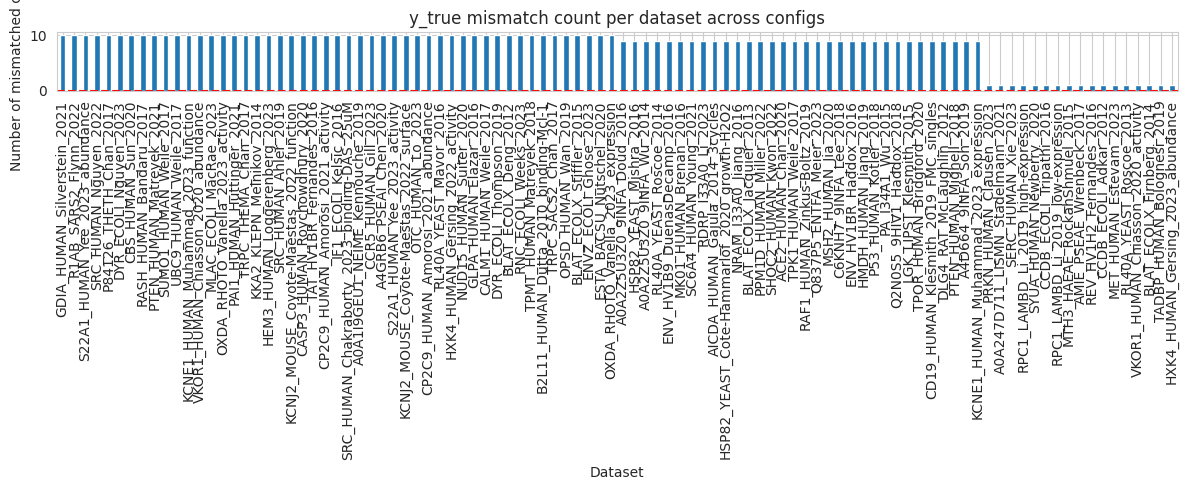

GDIA_HUMAN_Silverstein_2021           10
R1AB_SARS2_Flynn_2022                 10
S22A1_HUMAN_Yee_2023_abundance        10
SRC_HUMAN_Nguyen_2022                 10
P84126_THETH_Chan_2017                10
                                      ..
RL40A_YEAST_Roscoe_2013                1
VKOR1_HUMAN_Chiasson_2020_activity     1
BLAT_ECOLX_Firnberg_2014               1
TADBP_HUMAN_Bolognesi_2019             1
HXK4_HUMAN_Gersing_2023_abundance      1
Length: 98, dtype: int64


In [ ]:
mismatch_series = pd.Series(mismatch_count).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
mismatch_series.plot(kind='bar')
plt.axhline(0, color='red', linestyle='--')
plt.title('y_true mismatch count per dataset across configs')
plt.xlabel('Dataset')
plt.ylabel('Number of mismatched configs')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(mismatch_series[mismatch_series > 0])

In [ ]:
mismatch_series.value_counts().sort_index()

1     17
9     32
10    49
Name: count, dtype: int64

In [ ]:
zs_check = summary.groupby('dataset')['zeroshot_sr'].agg(['min', 'max', 'std'])
zs_check['range'] = zs_check['max'] - zs_check['min']
display(zs_check[zs_check['range'] > 0].sort_values('range', ascending=False))

,min,max,std,range
dataset,,,,


In [ ]:
summary_96 = summary[summary["shot"] == 96].copy()
summary_64 = summary[summary["shot"] == 64].copy()

In [ ]:
summary.groupby("dataset").size().describe()

count    116.000000
mean      24.965517
std        0.371391
min       21.000000
25%       25.000000
50%       25.000000
75%       25.000000
max       25.000000
dtype: float64

In [ ]:
base_dir = Path("/work/yunan/PsiFit/data/proteingym")
datasets = [d.name for d in base_dir.iterdir() if d.is_dir()]

In [ ]:
data = []

for dataset in datasets:
    fasta_path = base_dir / dataset / "wildtype.fasta"
    if fasta_path.exists():
        try:
            record = next(SeqIO.parse(fasta_path, "fasta"))
            seq = str(record.seq)
            length = len(seq)
            data.append({'dms_id': dataset, 'seq_length': length})
        except Exception as e:
            print(f"Error processing {fasta_path}: {e}")
            
df = pd.DataFrame(data)
df = df[~df['dms_id'].str.contains("Tsuboyama")]
df.sort_values(by='seq_length', ascending=True, inplace=True)

In [ ]:
short_df = df[df['seq_length'] <= 1022].copy().reset_index(drop=True)

In [ ]:
summary["dataset"].describe()

count                            2896
unique                            116
top       GDIA_HUMAN_Silverstein_2021
freq                               25
Name: dataset, dtype: object

In [ ]:
EXPECTED_PER_ATYPE = {
    "none": 1,             
    "single": 8,         
    "position-specific": 8,
    "context-specific": 8,
}
EXPECTED_TOTAL = sum(EXPECTED_PER_ATYPE.values())

issues = []

for (dataset, shot), grp in summary.groupby(["dataset", "shot"]):
    if len(grp) != EXPECTED_TOTAL:
        issues.append(f"[{dataset} | shot={shot}] total={len(grp)}, expected {EXPECTED_TOTAL}")

    for a_type, expected in EXPECTED_PER_ATYPE.items():
        count = len(grp[grp["a_type"] == a_type])
        if count != expected:
            issues.append(f"[{dataset} | shot={shot}] {a_type}: count={count}, expected {expected}")

if issues:
    print(f"ISSUES FOUND ({len(issues)}):")
    for msg in issues:
        print(" ", msg)
else:
    print(f"All datasets pass sanity check ({len(summary.groupby(['dataset','shot']))} dataset-shot pairs checked)")

ISSUES FOUND (4):
  [TRPC_THEMA_Chan_2017 | shot=96] total=21, expected 25
  [TRPC_THEMA_Chan_2017 | shot=96] single: count=7, expected 8
  [TRPC_THEMA_Chan_2017 | shot=96] position-specific: count=6, expected 8
  [TRPC_THEMA_Chan_2017 | shot=96] context-specific: count=7, expected 8


In [ ]:
summary['spearman_abs'] = summary['spearman'].abs()
summary_sorted = summary.sort_values(['dataset', 'spearman_abs'], ascending=[True, False])
best_per_dataset = summary_sorted.groupby('dataset').first().reset_index()

In [ ]:
print("=== Best configuration per dataset ===")
display(best_per_dataset[['dataset', "shot", 'a_type', 'a_init', 'combined_way', 'train_mode', 'spearman']])

=== Best configuration per dataset ===


,dataset,shot,a_type,a_init,combined_way,train_mode,spearman
0,A0A140D2T1_ZIKV_Sourisseau_2019,96,position-specific,-1.0,logits,full,0.160745
1,A0A192B1T2_9HIV1_Haddox_2018,96,single,-1.0,logits,a,0.614255
2,A0A1I9GEU1_NEIME_Kennouche_2019,96,single,0.1,scores,a,0.093634
3,A0A247D711_LISMN_Stadelmann_2021,96,single,-1.0,logits,full,0.417380
4,A0A2Z5U3Z0_9INFA_Doud_2016,96,single,-1.0,logits,full,0.611614
...,...,...,...,...,...,...,...
111,TRPC_SACS2_Chan_2017,96,position-specific,-1.0,scores,a,0.610164
112,TRPC_THEMA_Chan_2017,96,position-specific,-1.0,logits,full,0.632055
113,UBC9_HUMAN_Weile_2017,96,position-specific,-1.0,logits,full,0.602326
114,VKOR1_HUMAN_Chiasson_2020_abundance,96,position-specific,-1.0,logits,full,0.629988


In [ ]:
best_per_dataset.groupby(['shot', 'a_type',"a_init", "combined_way",'train_mode']).size().reset_index(name='count').sort_values('count', ascending=False)


,shot,a_type,a_init,combined_way,train_mode,count
6,96,position-specific,-1.0,logits,full,19
13,96,single,-1.0,logits,a,13
7,96,position-specific,-1.0,scores,a,11
8,96,position-specific,-1.0,scores,full,11
14,96,single,-1.0,logits,full,10
5,96,position-specific,-1.0,logits,a,7
4,96,none,0.1,scores,full,7
1,96,context-specific,-1.0,scores,a,7
3,96,context-specific,0.1,scores,full,6
2,96,context-specific,0.1,logits,full,4


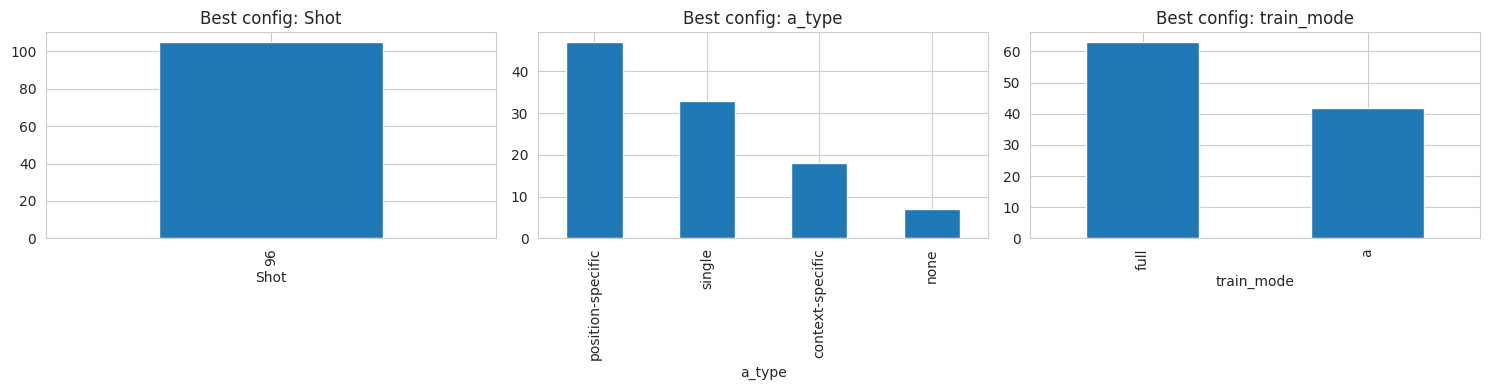

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

best_per_dataset['shot'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Best config: Shot')
axes[0].set_xlabel('Shot')

best_per_dataset['a_type'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Best config: a_type')
axes[1].set_xlabel('a_type')

best_per_dataset['train_mode'].value_counts().plot(kind='bar', ax=axes[2])
axes[2].set_title('Best config: train_mode')
axes[2].set_xlabel('train_mode')

plt.tight_layout()
plt.show()

=== Delta per method (averaged across datasets) ===


,shot,a_type,combined_way,train_mode,mean_delta,win_rate,n_datasets
9,96,single,logits,a,0.058293,0.612069,230
8,96,position-specific,scores,full,0.058057,0.607759,230
5,96,position-specific,logits,a,0.058020,0.610390,229
7,96,position-specific,scores,a,0.058002,0.610390,229
11,96,single,scores,a,0.058002,0.606061,229
12,96,single,scores,full,0.057972,0.612069,230
6,96,position-specific,logits,full,0.057777,0.603448,230
10,96,single,logits,full,0.057361,0.607759,230
3,96,context-specific,scores,full,0.053092,0.594828,230
2,96,context-specific,scores,a,0.052138,0.586207,230


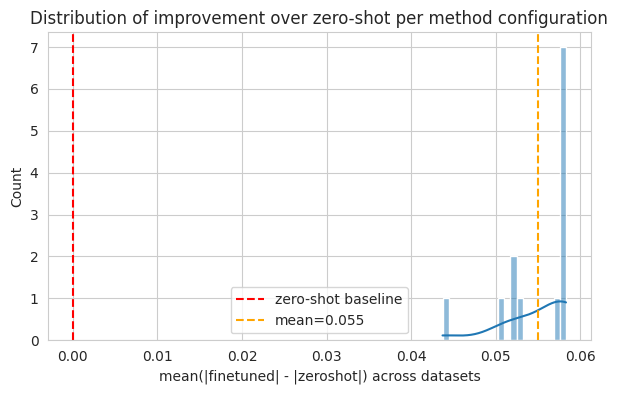


Configurations beating zero-shot on average: 13 / 13


In [ ]:
summary["delta"] = summary["spearman"].abs() - summary["zeroshot_sr"].abs()

method_cols = ['shot', 'a_type', 'combined_way', 'train_mode']

method_delta = (summary.groupby(method_cols)['delta']
                       .agg(mean_delta='mean',
                            win_rate=lambda x: (x > 0).mean(),
                            n_datasets='count')
                       .reset_index()
                       .sort_values('mean_delta', ascending=False))

print("=== Delta per method (averaged across datasets) ===")
display(method_delta)

plt.figure(figsize=(7, 4))
sns.histplot(method_delta['mean_delta'], bins=20, kde=True)
plt.axvline(0, color='red', linestyle='--', label='zero-shot baseline')
plt.axvline(method_delta['mean_delta'].mean(), color='orange', linestyle='--',
            label=f"mean={method_delta['mean_delta'].mean():.3f}")
plt.xlabel('mean(|finetuned| - |zeroshot|) across datasets')
plt.title('Distribution of improvement over zero-shot per method configuration')
plt.legend()
plt.show()

print(f"\nConfigurations beating zero-shot on average: "
      f"{(method_delta['mean_delta'] > 0).sum()} / {len(method_delta)}")

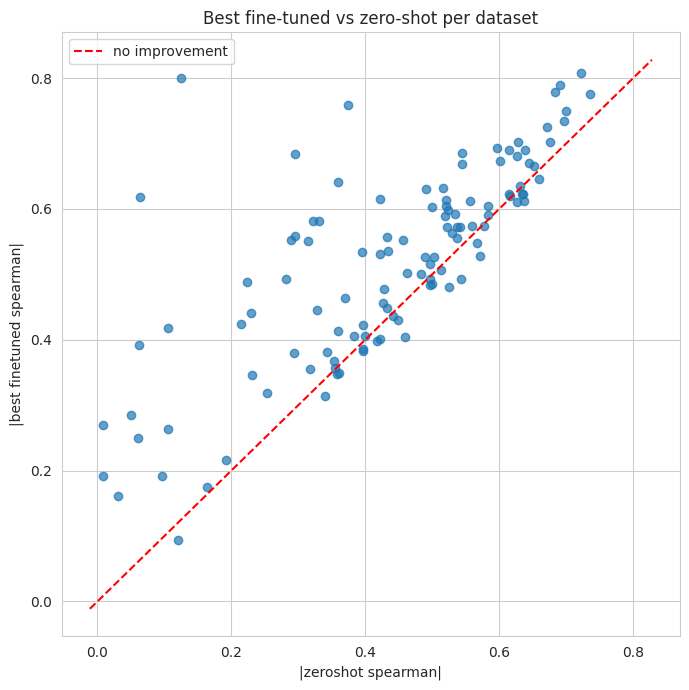

Datasets where fine-tuning wins: 90 / 116


In [ ]:
best_per_dataset = (summary.groupby('dataset')
                           .apply(lambda g: g.loc[g['spearman'].abs().idxmax()])
                           .reset_index(drop=True))

plt.figure(figsize=(7, 7))
plt.scatter(best_per_dataset['zeroshot_sr'].abs(),
            best_per_dataset['spearman'].abs(), alpha=0.7)

lim_min = min(best_per_dataset['zeroshot_sr'].abs().min(),
              best_per_dataset['spearman'].abs().min()) - 0.02
lim_max = max(best_per_dataset['zeroshot_sr'].abs().max(),
              best_per_dataset['spearman'].abs().max()) + 0.02
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label='no improvement')
plt.xlabel('|zeroshot spearman|')
plt.ylabel('|best finetuned spearman|')
plt.title('Best fine-tuned vs zero-shot per dataset')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Datasets where fine-tuning wins: "
      f"{(best_per_dataset['spearman'].abs() > best_per_dataset['zeroshot_sr'].abs()).sum()} "
      f"/ {len(best_per_dataset)}")


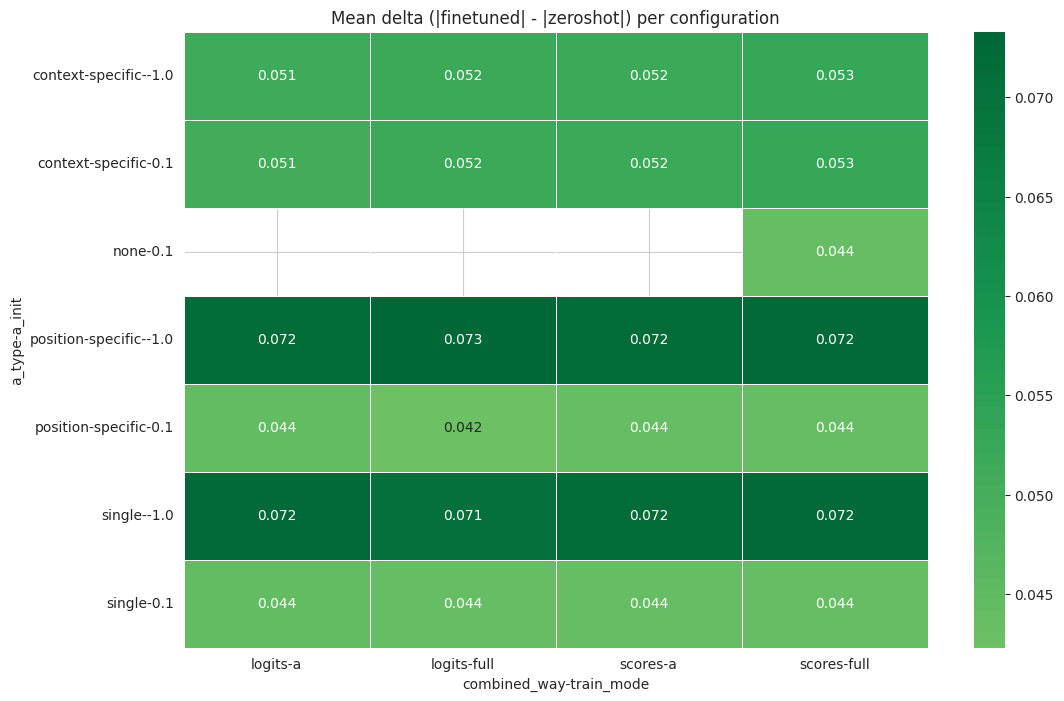

In [ ]:
pivot_delta = summary.pivot_table(
    values='delta',
    index=['a_type', 'a_init'],
    columns=['combined_way', 'train_mode'],
    aggfunc='mean'
).round(4)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_delta, annot=True, cmap='RdYlGn', center=0, fmt='.3f', linewidths=0.5)
plt.title('Mean delta (|finetuned| - |zeroshot|) per configuration')
plt.show()

=== Win rate and mean delta by a_type ===


,a_type,win_rate,mean_delta
0,context-specific,0.587918,0.052074
1,none,0.517241,0.043700
2,position-specific,0.607991,0.057964
3,single,0.609493,0.057907


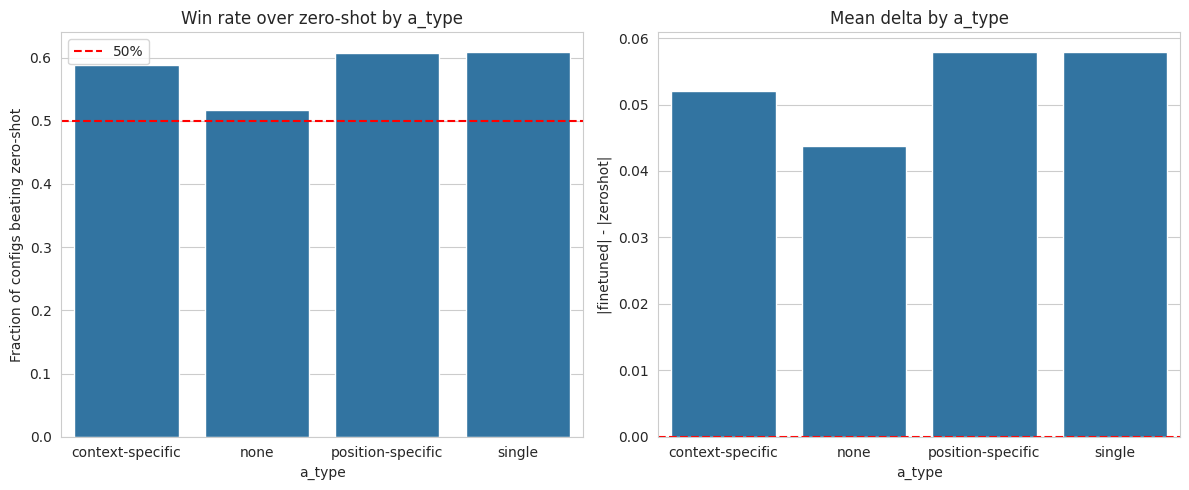

In [ ]:
winrate = (summary.groupby('a_type')
                  .apply(lambda g: (g['delta'] > 0).mean())
                  .reset_index()
                  .rename(columns={0: 'win_rate'}))

mean_delta_by_type = (summary.groupby('a_type')['delta']
                             .mean()
                             .reset_index()
                             .rename(columns={'delta': 'mean_delta'}))

atype_stats = winrate.merge(mean_delta_by_type, on='a_type')
print("=== Win rate and mean delta by a_type ===")
display(atype_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=atype_stats, x='a_type', y='win_rate', ax=axes[0])
axes[0].axhline(0.5, color='red', linestyle='--', label='50%')
axes[0].set_title('Win rate over zero-shot by a_type')
axes[0].set_ylabel('Fraction of configs beating zero-shot')
axes[0].legend()

sns.barplot(data=atype_stats, x='a_type', y='mean_delta', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Mean delta by a_type')
axes[1].set_ylabel('|finetuned| - |zeroshot|')
plt.tight_layout()
plt.show()

In [ ]:
summary_ab = summary.copy()
summary_ab['spearman_abs'] = summary_ab['spearman'].abs()

summary_ab = summary_ab.merge(short_df.rename(columns={'dms_id': 'dataset'}),
                              on='dataset', how='left')

summary_ab['zs_quartile']  = pd.qcut(summary_ab['zeroshot_sr'].abs(), q=4,
                                      labels=['Q1\n(hard)', 'Q2', 'Q3', 'Q4\n(easy)'])
summary_ab['len_quartile'] = pd.qcut(summary_ab['seq_length'], q=4,
                                      labels=['Q1\n(short)', 'Q2', 'Q3', 'Q4\n(long)'])

ps_vs_single = summary_ab[summary_ab['a_type'].isin(['position-specific', 'single'])]



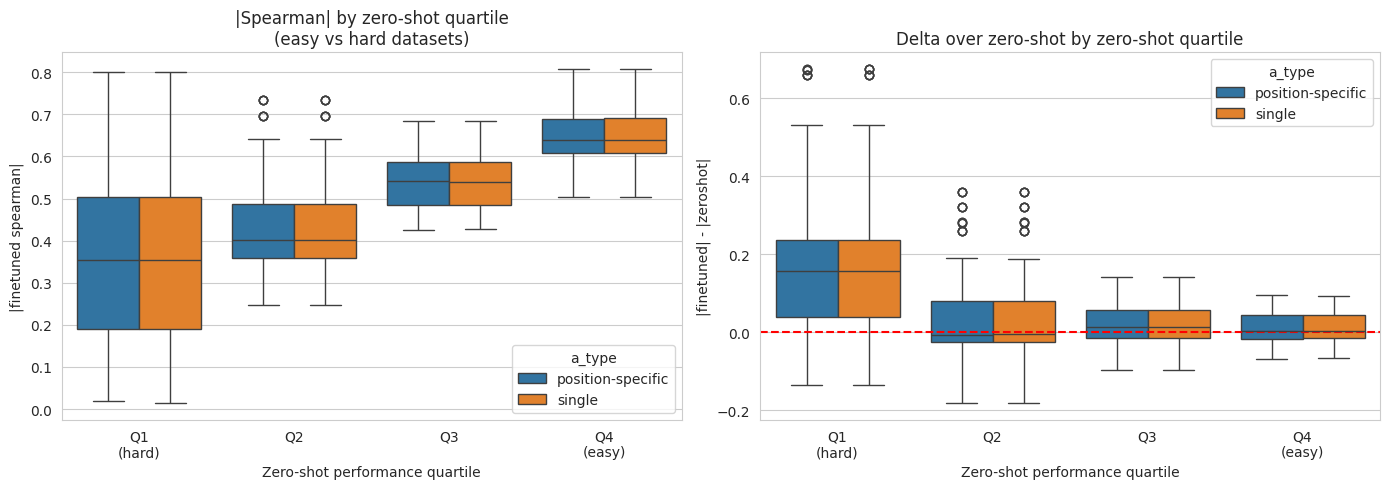

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=ps_vs_single, x='zs_quartile', y='spearman_abs',
            hue='a_type', ax=axes[0])
axes[0].set_title('|Spearman| by zero-shot quartile\n(easy vs hard datasets)')
axes[0].set_xlabel('Zero-shot performance quartile')
axes[0].set_ylabel('|finetuned spearman|')

sns.boxplot(data=ps_vs_single, x='zs_quartile', y='delta',
            hue='a_type', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Delta over zero-shot by zero-shot quartile')
axes[1].set_xlabel('Zero-shot performance quartile')
axes[1].set_ylabel('|finetuned| - |zeroshot|')
plt.tight_layout()
plt.show()

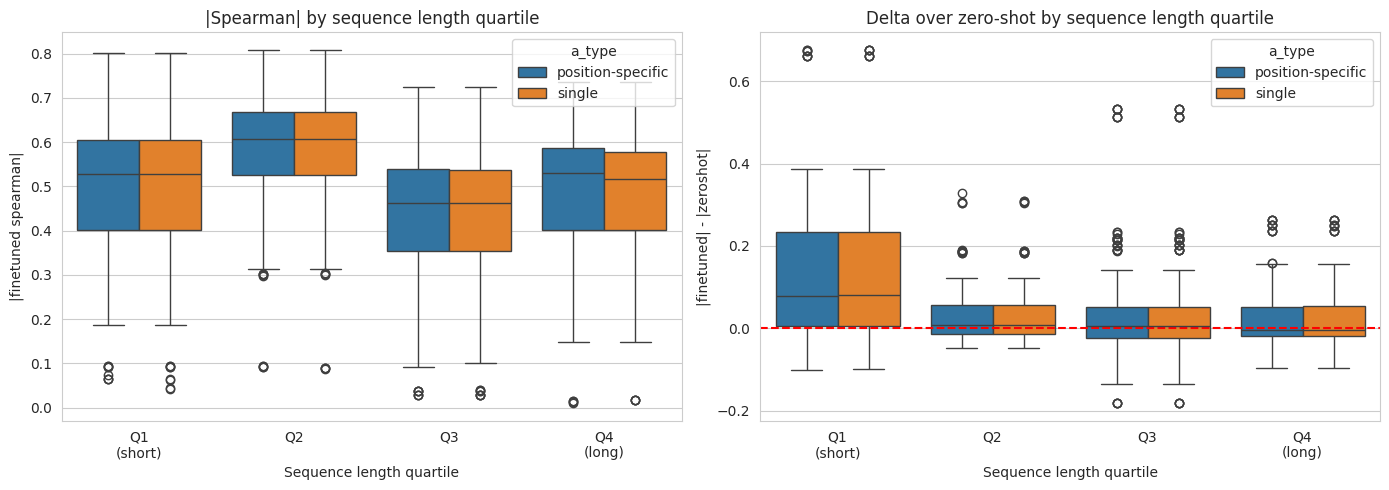

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=ps_vs_single, x='len_quartile', y='spearman_abs',
            hue='a_type', ax=axes[0])
axes[0].set_title('|Spearman| by sequence length quartile')
axes[0].set_xlabel('Sequence length quartile')
axes[0].set_ylabel('|finetuned spearman|')

sns.boxplot(data=ps_vs_single, x='len_quartile', y='delta',
            hue='a_type', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Delta over zero-shot by sequence length quartile')
axes[1].set_xlabel('Sequence length quartile')
axes[1].set_ylabel('|finetuned| - |zeroshot|')
plt.tight_layout()
plt.show()

In [ ]:
print("=== By zero-shot quartile ===")
display(ps_vs_single.groupby(['zs_quartile', 'a_type'])[['spearman_abs', 'delta']]
                    .mean().round(4))

print("\n=== By sequence length quartile ===")
display(ps_vs_single.groupby(['len_quartile', 'a_type'])[['spearman_abs', 'delta']]
                    .mean().round(4))

=== By zero-shot quartile ===


spearman_abs   delta
zs_quartile a_type                                 
Q1\n(hard)  position-specific        0.3786  0.1566
            single                   0.3747  0.1550
Q2          position-specific        0.4452  0.0307
            single                   0.4444  0.0303
Q3          position-specific        0.5452  0.0164
            single                   0.5454  0.0167
Q4\n(easy)  position-specific        0.6609  0.0137
            single                   0.6612  0.0139


=== By sequence length quartile ===


spearman_abs   delta
len_quartile a_type                                 
Q1\n(short)  position-specific        0.4964  0.1217
             single                   0.4971  0.1223
Q2           position-specific        0.5808  0.0298
             single                   0.5806  0.0297
Q3           position-specific        0.4446  0.0373
             single                   0.4442  0.0370
Q4\n(long)   position-specific        0.4913  0.0255
             single                   0.4836  0.0263

In [ ]:
ps_vs_single

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,zeroshot_sr,num_mutations,spearman_abs,delta,seq_length,zs_quartile,len_quartile
0,GDIA_HUMAN_Silverstein_2021,96,position-specific,-1.0,logits,full,0.482953,0.496445,234,0.482953,-0.013492,447,Q3,Q3
3,GDIA_HUMAN_Silverstein_2021,96,single,0.1,logits,full,0.460010,0.496445,234,0.460010,-0.036436,447,Q3,Q3
5,GDIA_HUMAN_Silverstein_2021,96,single,0.1,scores,full,0.460010,0.496445,234,0.460010,-0.036436,447,Q3,Q3
7,GDIA_HUMAN_Silverstein_2021,96,single,-1.0,scores,full,0.482611,0.496445,234,0.482611,-0.013834,447,Q3,Q3
8,GDIA_HUMAN_Silverstein_2021,96,position-specific,0.1,scores,full,0.460162,0.496445,234,0.460162,-0.036283,447,Q3,Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2572,HXK4_HUMAN_Gersing_2022_activity,96,single,0.1,logits,a,0.461607,0.499336,1716,0.461607,-0.037729,465,Q3,Q3
2573,HXK4_HUMAN_Gersing_2022_activity,96,position-specific,0.1,scores,a,0.461590,0.499336,1716,0.461590,-0.037746,465,Q3,Q3
2574,HXK4_HUMAN_Gersing_2022_activity,96,position-specific,0.1,logits,a,0.461602,0.499336,1716,0.461602,-0.037734,465,Q3,Q3
2575,HXK4_HUMAN_Gersing_2022_activity,96,single,-1.0,logits,a,0.484998,0.499336,1716,0.484998,-0.014338,465,Q3,Q3


In [ ]:
deep_seq = pd.read_excel("SPURS_SourceData.xlsx", sheet_name="fig4cd")

In [ ]:
deep_seq.head()

,protein,coarse_type,SPURS-augmented model,augmented model
0,BLAT_ECOLX_Firnberg_2014,OrganismalFitness,0.8315,0.7611
1,BLAT_ECOLX_Stiffler_2015,OrganismalFitness,0.8192,0.7583
2,GRB2_HUMAN_Faure_2021,OrganismalFitness,0.8173,0.6962
3,B2L11_HUMAN_Dutta_2010_binding-Mcl-1,Binding,0.7623,0.7812
4,CCDB_ECOLI_Adkar_2012,Activity,0.7562,0.7525


In [ ]:
best_with_deepseq = best_per_dataset.copy().merge(deep_seq, left_on="dataset", right_on="protein", how="left")

In [ ]:
best_with_deepseq[best_with_deepseq["protein"].isna()]#.sum()

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,zeroshot_sr,num_mutations,spearman_abs,delta,protein,coarse_type,SPURS-augmented model,augmented model
0,A0A140D2T1_ZIKV_Sourisseau_2019,96,position-specific,-1.0,logits,full,0.160745,NaN,1920,0.160745,NaN,NaN,NaN,NaN,NaN
30,ESTA_BACSU_Nutschel_2020,96,single,-1.0,logits,full,0.412788,0.359025,438,0.412788,0.053763,NaN,NaN,NaN,NaN


In [ ]:
deep_seq[deep_seq["protein"] == "ESTA_BACSU_Nutschel_2020"]

,protein,coarse_type,SPURS-augmented model,augmented model


In [ ]:
best_with_dseq = best_with_deepseq[~best_with_deepseq["protein"].isna()][["dataset", "spearman", "SPURS-augmented model", "augmented model"]]

In [ ]:
best_with_dseq

,dataset,spearman,SPURS-augmented model,augmented model
1,A0A1I9GEU1_NEIME_Kennouche_2019,0.093634,0.0676,0.0702
2,A0A247D711_LISMN_Stadelmann_2021,0.417380,0.5255,0.3451
3,A0A2Z5U3Z0_9INFA_Doud_2016,0.611614,0.6472,0.5326
4,A0A2Z5U3Z0_9INFA_Wu_2014,0.480403,0.5010,0.4557
5,A4GRB6_PSEAI_Chen_2020,0.750488,0.7561,0.6925
...,...,...,...,...
100,TRPC_SACS2_Chan_2017,0.610164,0.6281,0.5965
101,TRPC_THEMA_Chan_2017,0.632055,0.5606,0.5636
102,UBC9_HUMAN_Weile_2017,0.602326,0.5396,0.5592
103,VKOR1_HUMAN_Chiasson_2020_abundance,0.629988,0.5948,0.4672


In [ ]:
((best_with_dseq["spearman"] - best_with_dseq["augmented model"]) / best_with_dseq["augmented model"]).describe()

count    103.000000
mean       0.159398
std        0.525569
min       -0.634298
25%        0.010815
50%        0.081570
75%        0.178326
max        4.533894
dtype: float64

In [ ]:
((best_with_dseq["spearman"] - best_with_dseq["SPURS-augmented model"]) / best_with_dseq["SPURS-augmented model"]).describe()

count    103.000000
mean       0.017849
std        0.170902
min       -0.649653
25%       -0.039701
50%        0.003165
75%        0.093394
max        0.721449
dtype: float64

In [ ]:
### not aligned with SPURS dataset used
### "extra info used"

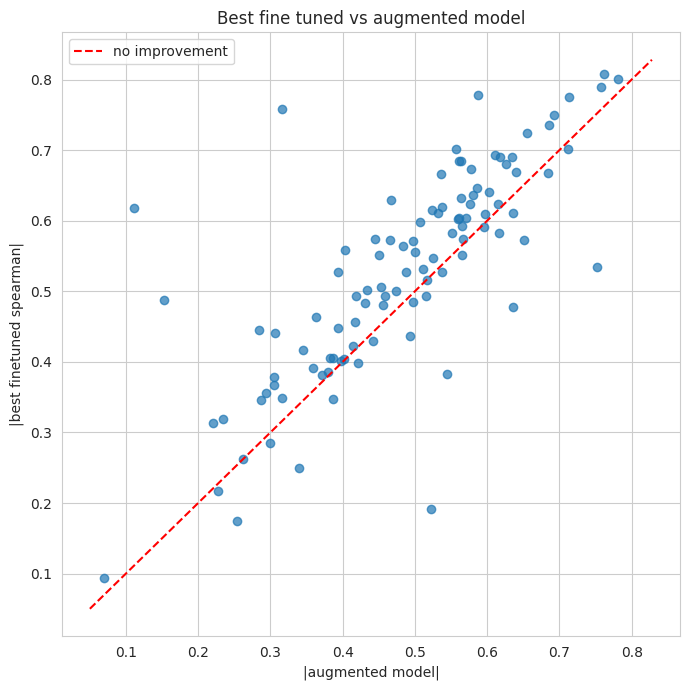

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(best_with_dseq["augmented model"].abs(),
            best_with_dseq["spearman"].abs(), alpha=0.7)
lim_min = min(best_with_dseq["augmented model"].abs().min(),
              best_with_dseq["spearman"].abs().min()) - 0.02
lim_max = max(best_with_dseq["augmented model"].abs().max(),
              best_with_dseq["spearman"].abs().max()) + 0.02
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label="no improvement")
plt.xlabel("|augmented model|")
plt.ylabel("|best finetuned spearman|")
plt.title("Best fine tuned vs augmented model")
plt.legend()
plt.tight_layout()
plt.show()

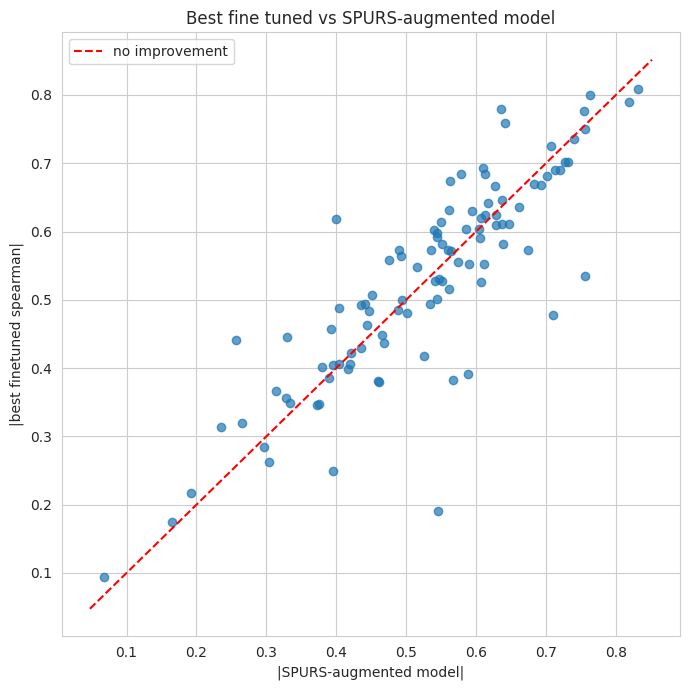

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(best_with_dseq["SPURS-augmented model"].abs(),
            best_with_dseq["spearman"].abs(), alpha=0.7)
lim_min = min(best_with_dseq["SPURS-augmented model"].abs().min(),
              best_with_dseq["spearman"].abs().min()) - 0.02
lim_max = max(best_with_dseq["SPURS-augmented model"].abs().max(),
              best_with_dseq["spearman"].abs().max()) + 0.02
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label="no improvement")
plt.xlabel("|SPURS-augmented model|")
plt.ylabel("|best finetuned spearman|")
plt.title("Best fine tuned vs SPURS-augmented model")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
zeroshot_scores

{'SCN5A_HUMAN_Glazer_2019':      mutant  esm1v_t33_650M_UR90S_1  esm1v_t33_650M_UR90S_2  \
 0    A1628C               -1.710391               -3.368973   
 1    A1628D               -1.068278               -5.904876   
 2    A1628E               -0.942350               -4.915349   
 3    A1628F                0.857721                0.640887   
 4    A1628G                0.056156               -0.957776   
 ..      ...                     ...                     ...   
 219  V1624R                0.545267               -2.411270   
 220  V1624S                0.283145               -0.829436   
 221  V1624T               -0.091693               -0.988472   
 222  V1624W               -1.418790               -3.001015   
 223  V1624Y               -0.699885               -2.249577   
 
      esm1v_t33_650M_UR90S_3  esm1v_t33_650M_UR90S_4  esm1v_t33_650M_UR90S_5  \
 0                 -1.951735               -2.230259               -2.593571   
 1                 -1.075414               

In [ ]:
old_root = Path("predicted")
new_root = Path("predicted_rerun_fixed")

def strip_shot(name):
    parts = name.split("_", 1)
    return parts[1] if parts[0].startswith("shot") else name

In [ ]:
datasets_old = {p.name for p in old_root.iterdir() if p.is_dir()}
datasets_new = {p.name for p in new_root.iterdir() if p.is_dir()}
common_datasets = sorted(datasets_old & datasets_new)
print(f"Datasets in old: {len(datasets_old)} | new: {len(datasets_new)} | common: {len(common_datasets)}")

Datasets in old: 116 | new: 105 | common: 105


In [ ]:
summary = []

for dataset in common_datasets:
    old_map = {strip_shot(p.name): p for p in (old_root / dataset).iterdir() if p.is_dir()}
    new_map = {strip_shot(p.name): p for p in (new_root / dataset).iterdir() if p.is_dir()}
    common_keys = sorted(old_map.keys() & new_map.keys())

    for key in common_keys:
        old_csv = old_map[key] / "pred.csv"
        new_csv = new_map[key] / "pred.csv"
        if not old_csv.exists() or not new_csv.exists():
            continue

        old_df = pd.read_csv(old_csv).drop_duplicates('mutation')
        new_df = pd.read_csv(new_csv).drop_duplicates('mutation')

        old_muts = set(old_df['mutation'].values)
        new_muts = set(new_df['mutation'].values)
        overlap = old_muts & new_muts
        overlap_pct = 100 * len(overlap) / max(len(old_muts), len(new_muts))

        if overlap:
            merged = pd.merge(
                old_df[old_df['mutation'].isin(overlap)][['mutation', 'y_true']],
                new_df[new_df['mutation'].isin(overlap)][['mutation', 'y_true']],
                on='mutation', suffixes=('_old', '_new')
            )
            ytrue_match = np.allclose(merged['y_true_old'].values, merged['y_true_new'].values, atol=1e-6)
            ytrue_max_diff = np.abs(merged['y_true_old'].values - merged['y_true_new'].values).max()
        else:
            ytrue_match = False
            ytrue_max_diff = np.nan

        summary.append({
            'dataset': dataset,
            'config': key,
            'n_old': len(old_df),
            'n_new': len(new_df),
            'overlap': len(overlap),
            'overlap_pct': round(overlap_pct, 1),
            'ytrue_match': ytrue_match,
            'ytrue_max_diff': ytrue_max_diff,
        })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

print(f"\nOverall:")
print(f"  Configs compared      : {len(summary_df)}")
print(f"  Full mutation overlap  : {(summary_df['overlap_pct'] == 100).sum()}")
print(f"  y_true match (overlap) : {summary_df['ytrue_match'].sum()} / {len(summary_df)}")
print(f"  Avg overlap %          : {summary_df['overlap_pct'].mean():.1f}%")


                                    dataset                                                               config  n_old  n_new  overlap  overlap_pct  ytrue_match  ytrue_max_diff
            A0A140D2T1_ZIKV_Sourisseau_2019  seed1_modecontext-specific_ainit-1.0_combinedlogits_trainmodea_only   1915   1915     1915        100.0         True             0.0
            A0A140D2T1_ZIKV_Sourisseau_2019    seed1_modecontext-specific_ainit-1.0_combinedlogits_trainmodefull   1915   1915     1915        100.0         True             0.0
            A0A140D2T1_ZIKV_Sourisseau_2019  seed1_modecontext-specific_ainit-1.0_combinedscores_trainmodea_only   1915   1915     1915        100.0         True             0.0
            A0A140D2T1_ZIKV_Sourisseau_2019    seed1_modecontext-specific_ainit-1.0_combinedscores_trainmodefull   1915   1915     1915        100.0         True             0.0
            A0A140D2T1_ZIKV_Sourisseau_2019   seed1_modecontext-specific_ainit0.1_combinedlogits_trainmodea_on

In [ ]:
pd.read_csv("/work/yunan/PsiFit/data/proteingym/IF1_ECOLI_Kelsic_2016/proteingym_dms.tsv", sep='\t')

,mutant,DMS_score
0,M1H,0.147500
1,M1G,-0.001750
2,M1I,0.118000
3,M1L,0.080333
4,M1N,0.407500
...,...,...
1362,R72S,0.923333
1363,R72T,0.911000
1364,R72V,0.904750
1365,R72D,0.853500


In [ ]:
data = []
for file in tqdm(result_files):
    parts = file.parts
    dataset = parts[1]
    folder_name = parts[2]
    
    try:
        params = folder_name.split("_")
        if params[0].startswith("shot"):
            shot         = int(params[0].replace("shot", ""))
            model_seed   = params[1].replace("seed", "")
            a_type       = params[2].replace("mode", "")
            a_init       = params[3].replace("ainit", "")
            combined_way = params[4].replace("combined", "")
            train_mode   = params[5].replace("trainmode", "")
        # else:
        #     shot         = 96
        #     model_seed   = params[0].replace("seed", "")
        #     a_type       = params[1].replace("mode", "")
        #     a_init       = params[2].replace("ainit", "")
        #     combined_way = params[3].replace("combined", "")
        #     train_mode   = params[4].replace("trainmode", "")
        # # print(f"{folder_name}")
        if a_type == "none" and a_init == "-1.0":
            continue
        
        df = pd.read_csv(file)
        
        if "1" in df.columns and "y_true" in df.columns:
            sr = spearmanr(df["1"], df["y_true"]).correlation
        else:
            sr = np.nan
            
        data.append({
            "dataset": dataset,
            "shot": shot,
            "a_type": a_type,
            "a_init": a_init,
            "combined_way": combined_way,
            "train_mode": train_mode,
            "spearman": sr,
            "num_mutations": len(df)
        })
    except:
        print(f"Skipping malformed folder:{dataset}{folder_name}")
        continue

summary = pd.DataFrame(data)
print("summary type:", summary.shape)
summary.head()

 65%|██████▍   | 3763/5807 [00:06<00:03, 566.67it/s]

Skipping malformed folder:IF1_ECOLI_Kelsic_2016shot96_seed1_modecontext-specific_ainit0.1_combinedlogits
Skipping malformed folder:IF1_ECOLI_Kelsic_2016shot96_seed1_modesingle_ainit0.1_combinedscores
Skipping malformed folder:IF1_ECOLI_Kelsic_2016shot96_seed1_modecontext-specific_ainit0.1_combinedscores
Skipping malformed folder:IF1_ECOLI_Kelsic_2016shot96_seed1_modeposition-specific_ainit-1.0_combinedscores
Skipping malformed folder:IF1_ECOLI_Kelsic_2016shot96_seed1_modesingle_ainit-1.0_combinedscores
Skipping malformed folder:IF1_ECOLI_Kelsic_2016shot96_seed1_modecontext-specific_ainit-1.0_combinedscores


100%|██████████| 5807/5807 [00:10<00:00, 556.52it/s]

summary type: (5800, 8)


,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
0,GDIA_HUMAN_Silverstein_2021,64,position-specific,-1.0,logits,full,0.480225,234
1,GDIA_HUMAN_Silverstein_2021,96,position-specific,-1.0,logits,full,0.481662,232
2,GDIA_HUMAN_Silverstein_2021,64,single,-1.0,scores,a,0.480312,234
3,GDIA_HUMAN_Silverstein_2021,64,single,0.1,logits,full,0.458726,234
4,GDIA_HUMAN_Silverstein_2021,96,context-specific,-1.0,scores,a,0.444432,234


In [ ]:
best_per_dataset.groupby(['shot', 'a_type', 'train_mode']).size().reset_index(name='count').sort_values('count', ascending=False)

,shot,a_type,train_mode,count
9,96,position-specific,full,55
11,96,single,full,14
0,64,context-specific,full,10
2,64,position-specific,full,9
6,96,context-specific,full,9
3,64,single,a,9
4,64,single,full,4
7,96,none,full,2
1,64,position-specific,a,1
5,96,context-specific,a,1


In [ ]:
base_dir = Path("/work/yunan/PsiFit/data/proteingym")
datasets = [d.name for d in base_dir.iterdir() if d.is_dir()]
short_df = df[df['seq_length'] <= 1022].copy().reset_index(drop=True)

In [ ]:
summary_with_len = summary.merge(short_df[['dms_id', 'seq_length']], 
                                  left_on='dataset', right_on='dms_id', how='left')

In [ ]:
best = summary_with_len.groupby(['dataset', 'seq_length'])['spearman'].max().reset_index()

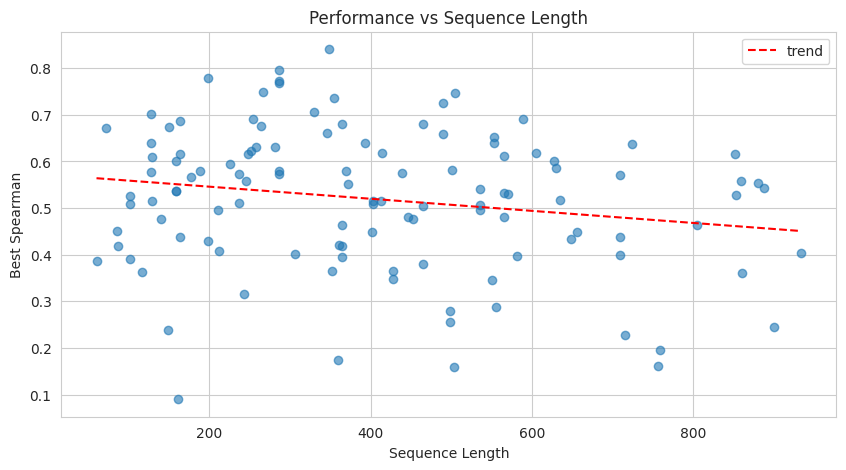

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(best['seq_length'], best['spearman'], alpha=0.6)

z = np.polyfit(best['seq_length'], best['spearman'], 1)
p = np.poly1d(z)
x_line = np.linspace(best['seq_length'].min(), best['seq_length'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', label='trend')

plt.xlabel('Sequence Length')
plt.ylabel('Best Spearman')
plt.title('Performance vs Sequence Length')
plt.legend()
plt.show()

In [ ]:
pivot_init = summary[summary['a_type'] != 'none'].pivot_table(
    values='spearman',
    index=['a_type', 'combined_way', 'train_mode', 'shot'],
    columns='a_init',
    aggfunc='mean'
).round(4)

pivot_init['diff (0.1 - (-1.0))'] = pivot_init['0.1'] - pivot_init['-1.0']
display(pivot_init)

a_init                                            -1.0     0.1  \
a_type            combined_way train_mode shot                   
context-specific  logits       a          64    0.4635  0.4635   
                                          96    0.4635  0.4635   
                               full       64    0.4600  0.4600   
                                          96    0.4738  0.4738   
                  scores       a          64    0.4639  0.4638   
                                          96    0.4639  0.4639   
                               full       64    0.4677  0.4603   
                                          96    0.4609  0.4731   
position-specific logits       a          64    0.4819  0.4457   
                                          96    0.4819  0.4457   
                               full       64    0.4822  0.4447   
                                          96    0.5023  0.4621   
                  scores       a          64    0.4819  0.4458   
                                          96    0.4819  0.4458   
                               full       64    0.4819  0.4459   
                                          96    0.5009  0.4631   
single            logits       a          64    0.4819  0.4459   
                                          96    0.4819  0.4459   
                               full       64    0.4815  0.4456   
                                          96    0.4815  0.4456   
                  scores       a          64    0.4819  0.4459   
                                          96    0.4819  0.4459   
                               full       64    0.4819  0.4458   
                                          96    0.5014  0.4635   

a_init                                          diff (0.1 - (-1.0))  
a_type            combined_way train_mode shot                       
context-specific  logits       a          64                 0.0000  
                                          96                 0.0000  
                               full       64                 0.0000  
                                          96                 0.0000  
                  scores       a          64                -0.0001  
                                          96                 0.0000  
                               full       64                -0.0074  
                                          96                 0.0122  
position-specific logits       a          64                -0.0362  
                                          96                -0.0362  
                               full       64                -0.0375  
                                          96                -0.0402  
                  scores       a          64                -0.0361  
                                          96                -0.0361  
                               full       64                -0.0360  
                                          96                -0.0378  
single            logits       a          64                -0.0360  
                                          96                -0.0360  
                               full       64                -0.0359  
                                          96                -0.0359  
                  scores       a          64                -0.0360  
                                          96                -0.0360  
                               full       64                -0.0361  
                                          96                -0.0379

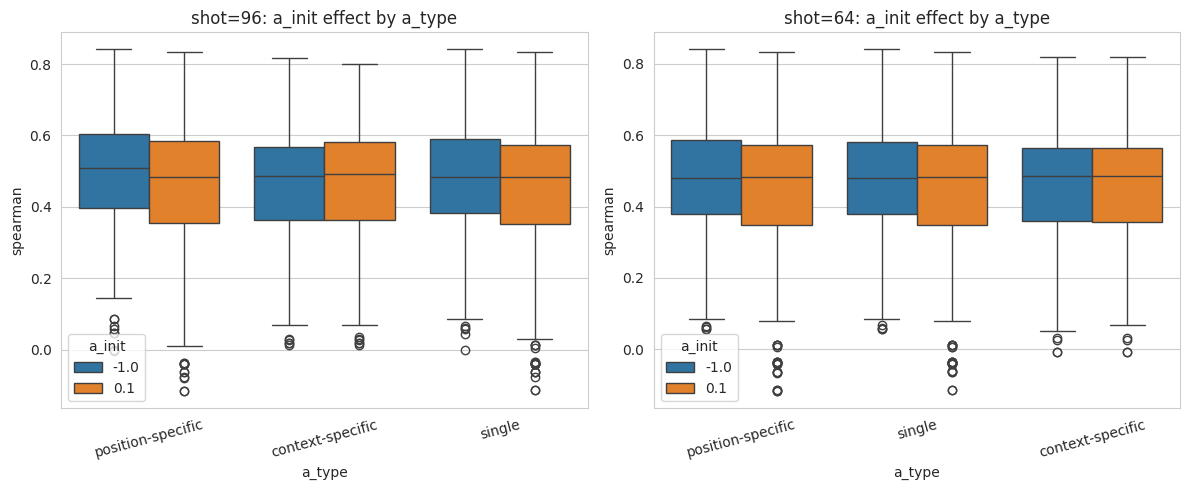

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, shot in zip(axes, [96, 64]):
    sub = summary[(summary['a_type'] != 'none') & (summary['shot'] == shot)]
    sns.boxplot(data=sub, x='a_type', y='spearman', hue='a_init', ax=ax)
    ax.set_title(f'shot={shot}: a_init effect by a_type')
    ax.set_xlabel('a_type')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
summary.head()

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,zeroshot_sr,num_mutations,spearman_abs,delta
0,GDIA_HUMAN_Silverstein_2021,64,position-specific,-1.0,logits,full,0.480225,0.496445,234,0.480225,-0.016221
1,GDIA_HUMAN_Silverstein_2021,96,position-specific,-1.0,logits,full,0.481662,0.495730,232,0.481662,-0.014068
2,GDIA_HUMAN_Silverstein_2021,64,single,-1.0,scores,a,0.480312,0.496445,234,0.480312,-0.016133
3,GDIA_HUMAN_Silverstein_2021,64,single,0.1,logits,full,0.458726,0.496445,234,0.458726,-0.037720
4,GDIA_HUMAN_Silverstein_2021,96,context-specific,-1.0,scores,a,0.444432,0.496445,234,0.444432,-0.052014


In [ ]:
zeroshot_scores

{'SCN5A_HUMAN_Glazer_2019':      mutant  esm1v_t33_650M_UR90S_1  esm1v_t33_650M_UR90S_2  \
 0    A1628C               -1.710391               -3.368973   
 1    A1628D               -1.068278               -5.904876   
 2    A1628E               -0.942350               -4.915349   
 3    A1628F                0.857721                0.640887   
 4    A1628G                0.056156               -0.957776   
 ..      ...                     ...                     ...   
 219  V1624R                0.545267               -2.411270   
 220  V1624S                0.283145               -0.829436   
 221  V1624T               -0.091693               -0.988472   
 222  V1624W               -1.418790               -3.001015   
 223  V1624Y               -0.699885               -2.249577   
 
      esm1v_t33_650M_UR90S_3  esm1v_t33_650M_UR90S_4  esm1v_t33_650M_UR90S_5  \
 0                 -1.951735               -2.230259               -2.593571   
 1                 -1.075414               

In [ ]:
temp_test_df = pd.read_csv("data/A0A1I9GEU1_NEIME_Kennouche_2019/test.csv")

In [ ]:
temp_test_df.head()

,Unnamed: 0,seq,log_fitness,n_mut,mutant,PID,mutated_position
0,608,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,0.896,1,S106F,608,105
1,350,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,1.641,1,S62N,350,61
2,299,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,-0.872,1,H54D,299,53
3,726,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,2.593,1,T127A,726,126
4,253,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKPA...,0.375,1,S45P,253,44


In [ ]:
temp_pred_df = pd.read_csv("predicted/A0A1I9GEU1_NEIME_Kennouche_2019/shot64_seed1_modecontext-specific_ainit-1.0_combinedlogits_trainmodea_only/pred.csv")

In [ ]:
temp_pred_df.head()

,1,mutation,y_true
0,-4.132582,0,0.896
1,-0.322371,1,1.641
2,0.028641,2,-0.872
3,0.380773,3,2.593
4,-5.395401,4,0.375


In [ ]:
zeroshot_scores

{'SCN5A_HUMAN_Glazer_2019':      mutant  esm1v_t33_650M_UR90S_1  esm1v_t33_650M_UR90S_2  \
 0    A1628C               -1.710391               -3.368973   
 1    A1628D               -1.068278               -5.904876   
 2    A1628E               -0.942350               -4.915349   
 3    A1628F                0.857721                0.640887   
 4    A1628G                0.056156               -0.957776   
 ..      ...                     ...                     ...   
 219  V1624R                0.545267               -2.411270   
 220  V1624S                0.283145               -0.829436   
 221  V1624T               -0.091693               -0.988472   
 222  V1624W               -1.418790               -3.001015   
 223  V1624Y               -0.699885               -2.249577   
 
      esm1v_t33_650M_UR90S_3  esm1v_t33_650M_UR90S_4  esm1v_t33_650M_UR90S_5  \
 0                 -1.951735               -2.230259               -2.593571   
 1                 -1.075414               

In [ ]:
best_with_dseq

,dataset,spearman,SPURS-augmented model,augmented model
1,A0A192B1T2_9HIV1_Haddox_2018,0.615397,0.5597,0.4635
2,A0A1I9GEU1_NEIME_Kennouche_2019,0.089923,0.0676,0.0702
3,A0A247D711_LISMN_Stadelmann_2021,0.417739,0.5255,0.3451
4,A0A2Z5U3Z0_9INFA_Doud_2016,0.612296,0.6472,0.5326
5,A0A2Z5U3Z0_9INFA_Wu_2014,0.481551,0.5010,0.4557
...,...,...,...,...
111,TRPC_SACS2_Chan_2017,0.615708,0.6281,0.5965
112,TRPC_THEMA_Chan_2017,0.623462,0.5606,0.5636
113,UBC9_HUMAN_Weile_2017,0.600307,0.5396,0.5592
114,VKOR1_HUMAN_Chiasson_2020_abundance,0.616721,0.5948,0.4672


In [ ]:
((best_with_dseq["spearman"].abs() - best_with_dseq["SPURS-augmented model"].abs()) / best_with_dseq["SPURS-augmented model"].abs()).mean()

np.float64(0.013748151652490685)

In [ ]:
((best_with_dseq["spearman"].abs() - best_with_dseq["augmented model"].abs()) / best_with_dseq["augmented model"].abs()).mean()

np.float64(0.1515463658163882)

,dms_id,seq_length
0,ENVZ_ECOLI_Ghose_2023,60
1,IF1_ECOLI_Kelsic_2016,72
2,TAT_HV1BR_Fernandes_2016,86
3,A0A247D711_LISMN_Stadelmann_2021,87
4,CCDB_ECOLI_Adkar_2012,101
...,...,...
111,ENV_HV1BR_Haddox_2016,861
112,GAL4_YEAST_Kitzman_2015,881
113,HMDH_HUMAN_Jiang_2019,888
114,POLG_DEN26_Suphatrakul_2023,900


In [ ]:
best_with_dseq.copy().merge(short_df, left_on="dataset", right_on="dms_id", how="left")

,dataset,spearman,SPURS-augmented model,augmented model,dms_id,seq_length
0,A0A192B1T2_9HIV1_Haddox_2018,0.615397,0.5597,0.4635,A0A192B1T2_9HIV1_Haddox_2018,852
1,A0A1I9GEU1_NEIME_Kennouche_2019,0.089923,0.0676,0.0702,A0A1I9GEU1_NEIME_Kennouche_2019,161
2,A0A247D711_LISMN_Stadelmann_2021,0.417739,0.5255,0.3451,A0A247D711_LISMN_Stadelmann_2021,87
3,A0A2Z5U3Z0_9INFA_Doud_2016,0.612296,0.6472,0.5326,A0A2Z5U3Z0_9INFA_Doud_2016,565
4,A0A2Z5U3Z0_9INFA_Wu_2014,0.481551,0.5010,0.4557,A0A2Z5U3Z0_9INFA_Wu_2014,565
...,...,...,...,...,...,...
109,TRPC_SACS2_Chan_2017,0.615708,0.6281,0.5965,TRPC_SACS2_Chan_2017,248
110,TRPC_THEMA_Chan_2017,0.623462,0.5606,0.5636,TRPC_THEMA_Chan_2017,252
111,UBC9_HUMAN_Weile_2017,0.600307,0.5396,0.5592,UBC9_HUMAN_Weile_2017,159
112,VKOR1_HUMAN_Chiasson_2020_abundance,0.616721,0.5948,0.4672,VKOR1_HUMAN_Chiasson_2020_abundance,163


In [ ]:
summary_with_len

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,zeroshot_sr,num_mutations,spearman_abs,delta,dms_id,seq_length
0,GDIA_HUMAN_Silverstein_2021,64,position-specific,-1.0,logits,full,0.480225,0.496445,234,0.480225,-0.016221,GDIA_HUMAN_Silverstein_2021,447
1,GDIA_HUMAN_Silverstein_2021,96,position-specific,-1.0,logits,full,0.481662,0.495730,232,0.481662,-0.014068,GDIA_HUMAN_Silverstein_2021,447
2,GDIA_HUMAN_Silverstein_2021,64,single,-1.0,scores,a,0.480312,0.496445,234,0.480312,-0.016133,GDIA_HUMAN_Silverstein_2021,447
3,GDIA_HUMAN_Silverstein_2021,64,single,0.1,logits,full,0.458726,0.496445,234,0.458726,-0.037720,GDIA_HUMAN_Silverstein_2021,447
4,GDIA_HUMAN_Silverstein_2021,96,context-specific,-1.0,scores,a,0.444432,0.496445,234,0.444432,-0.052014,GDIA_HUMAN_Silverstein_2021,447
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5795,HXK4_HUMAN_Gersing_2022_activity,64,single,0.1,logits,a,0.456929,0.499336,1716,0.456929,-0.042407,HXK4_HUMAN_Gersing_2022_activity,465
5796,HXK4_HUMAN_Gersing_2022_activity,64,context-specific,-1.0,logits,a,0.459923,0.499336,1716,0.459923,-0.039413,HXK4_HUMAN_Gersing_2022_activity,465
5797,HXK4_HUMAN_Gersing_2022_activity,96,position-specific,-1.0,logits,a,0.480623,0.499336,1716,0.480623,-0.018713,HXK4_HUMAN_Gersing_2022_activity,465
5798,HXK4_HUMAN_Gersing_2022_activity,96,context-specific,0.1,scores,a,0.459916,0.499336,1716,0.459916,-0.039420,HXK4_HUMAN_Gersing_2022_activity,465


In [ ]:
zeroshot_scores["A0A140D2T1_ZIKV_Sourisseau_2019"]

,mutant,esm1v_t33_650M_UR90S_1,esm1v_t33_650M_UR90S_2,esm1v_t33_650M_UR90S_3,esm1v_t33_650M_UR90S_4,esm1v_t33_650M_UR90S_5,Ensemble_ESM1v
0,A325C,-1.249530,0.074630,-1.532469,-0.965854,-1.333555,-1.001356
1,A325D,-0.013942,-0.457033,-0.011102,-0.212188,0.137986,-0.111256
2,A325E,-0.204072,-0.415692,-0.267130,-0.457461,-0.239990,-0.316869
3,A325F,-1.056552,-2.105740,-0.932103,-0.968806,-1.210128,-1.254666
4,A325G,0.263416,-0.161992,0.144216,0.241656,0.289303,0.155320
...,...,...,...,...,...,...,...
9571,Y676R,1.161477,-3.549694,0.674065,0.547645,0.911667,-0.050968
9572,Y676S,1.552789,-2.457444,1.174242,0.982226,1.292838,0.508930
9573,Y676T,1.243415,-2.834986,1.022631,0.927928,1.092464,0.290290
9574,Y676V,1.095783,-2.230103,0.799054,1.061688,1.075942,0.360473


In [ ]:
result_files[0] #.parts[1]["A0A140D2T1_ZIKV_Sourisseau_2019"]

PosixPath('predicted/GDIA_HUMAN_Silverstein_2021/shot64_seed1_modeposition-specific_ainit-1.0_combinedlogits_trainmodefull/pred.csv')

In [ ]:
ds = "A0A140D2T1_ZIKV_Sourisseau_2019"
error_seq = str(next(SeqIO.parse(f"data/{ds}/wt.fasta", "fasta")).seq)

In [ ]:
error_seq[324]

'T'

In [ ]:
total_nonfound, total_mismatch, total_error

({'A0A140D2T1_ZIKV_Sourisseau_2019': np.int64(1874)}, {}, {})

In [ ]:
ds = "A0A140D2T1_ZIKV_Sourisseau_2019"
temp_zsdf = pd.DataFrame(zeroshot_scores[ds][["mutant","Ensemble_ESM1v"]])
temp_wt = str(next(SeqIO.parse(f"data/{ds}/wt.fasta", "fasta")).seq)

In [ ]:
temp_zsdf

,mutant,Ensemble_ESM1v
0,A325C,-1.001356
1,A325D,-0.111256
2,A325E,-0.316869
3,A325F,-1.254666
4,A325G,0.155320
...,...,...
9571,Y676R,-0.050968
9572,Y676S,0.508930
9573,Y676T,0.290290
9574,Y676V,0.360473


In [ ]:
temp_testdf = pd.read_csv(f'data/{ds}/test.csv')
inner_merge = temp_testdf.copy().merge(temp_zsdf, on='mutant', how='inner')
left_merge = temp_testdf.copy().merge(temp_zsdf, on='mutant', how='left')

In [ ]:
len(temp_zsdf), len(temp_testdf), len(inner_merge), len(left_merge)

(9576, 1915, 41, 1915)

In [ ]:
left_merge["Ensemble_ESM1v"].isna().sum()

np.int64(1874)

In [ ]:
temp_testdf.head()

,Unnamed: 0,seq,log_fitness,n_mut,mutant,PID,mutated_position
0,3243,IRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.093951,1,P171S,3243,170
1,5061,IRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.175046,1,T267I,5061,266
2,9,CRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.050461,1,I1C,9,0
3,888,IRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.229059,1,T47S,888,46
4,5065,IRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.060813,1,T267E,5065,266


In [ ]:
left_merge

,Unnamed: 0,seq,log_fitness,n_mut,mutant,PID,mutated_position,Ensemble_ESM1v
0,3243,IRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.093951,1,P171S,3243,170,NaN
1,5061,IRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.175046,1,T267I,5061,266,NaN
2,9,CRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.050461,1,I1C,9,0,NaN
3,888,IRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.229059,1,T47S,888,46,NaN
4,5065,IRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.060813,1,T267E,5065,266,NaN
...,...,...,...,...,...,...,...,...
1910,7907,IRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.019061,1,G417V,7907,416,0.539576
1911,7205,IRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.008613,1,P380G,7205,379,NaN
1912,491,IRCIGVSNRDFVEGMSGGTWVDVVLYHGGCVTVMAQDKPTVDIELV...,0.017806,1,E26Y,491,25,NaN
1913,8909,IRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,0.023575,1,G469N,8909,468,NaN


In [ ]:
temp_wt[434]

'G'

In [ ]:
# temp_path = Path("/work/yunan/PsiFit/data/proteingym")
# temp_df = pd.read_csv(temp_path / ds / "proteingym_dms.tsv", sep='\t')

In [ ]:
def apply_mutations(mutant):
    seq_list = list(wt)
    mutations = mutant.split(':')
    for mut in mutations:
        if len(mut) < 3:
            raise ValueError(f"Invalid mutant format: {mut}")
        wild_aa, pos_str, mut_aa = mut[0], mut[1:-1], mut[-1]
        # print(wild_aa, pos_str, mut_aa)
        pos = int(pos_str)
        if seq_list[pos - 1] != wild_aa:
            raise ValueError(f"Mismatch at position {pos}: expected {wild_aa}, found {seq_list[pos - 1]}")
        seq_list[pos - 1] = mut_aa
    return ''.join(seq_list)
temp_df['mutated_sequence'] = temp_df['mutant'].apply(apply_mutations)

In [ ]:
temp_df.head()

,mutant,DMS_score,mutated_sequence
0,H24C,-3.924478,MSIQHFRVALIPFFAAFCLPVFACPETLVKVKDAEDQLGARVGYIE...
1,H24Y,-2.170022,MSIQHFRVALIPFFAAFCLPVFAYPETLVKVKDAEDQLGARVGYIE...
2,H24W,-4.345218,MSIQHFRVALIPFFAAFCLPVFAWPETLVKVKDAEDQLGARVGYIE...
3,H24V,-3.011503,MSIQHFRVALIPFFAAFCLPVFAVPETLVKVKDAEDQLGARVGYIE...
4,H24T,-1.565248,MSIQHFRVALIPFFAAFCLPVFATPETLVKVKDAEDQLGARVGYIE...


In [ ]:
data = []
for file in tqdm(result_files):
    parts = file.parts
    dataset = parts[1]
    folder_name = parts[2]
    
    try:
        params = folder_name.split("_")
        if params[0].startswith("shot"):
            shot         = int(params[0].replace("shot", ""))
            model_seed   = params[1].replace("seed", "")
            a_type       = params[2].replace("mode", "")
            a_init       = params[3].replace("ainit", "")
            combined_way = params[4].replace("combined", "")
            train_mode   = params[5].replace("trainmode", "")
        if a_type == "none" and a_init == "-1.0":
            continue
        
        df = pd.read_csv(file)
        
        if "1" in df.columns and "y_true" in df.columns:
            sr = spearmanr(df["1"], df["y_true"]).correlation
        else:
            sr = np.nan

        # compute zero-shot spearman for the same test split
        zs_sr = np.nan
        if dataset in zeroshot_scores:
            test_csv = pd.read_csv(f'data/{dataset}/test.csv')
            wt_seq = str(next(SeqIO.parse(f"data/{dataset}/wt.fasta", "fasta")).seq)
            def apply_mutations(mutant):
                seq_list = list(wt_seq)
                mutations = mutant.split(":")
                for mut in mutations:
                    if len(mut) < 3:
                        raise ValueError(f"Invalid mutant format:"{mut}"")
                    wild_aa, pos_str, mut_aa = mut[0]
                
            df['mutant'] = df['mutation'].apply(lambda i: test_csv.iloc[i]['mutant'])
            zs = zeroshot_scores[dataset][['mutant', 'Ensemble_ESM1v']]
            merged = df.merge(zs, on='mutant', how='inner')
            if len(merged) > 0 and merged['Ensemble_ESM1v'].notna().any():
                zs_sr = spearmanr(merged['Ensemble_ESM1v'], merged['y_true']).correlation

        data.append({
            "dataset": dataset,
            "shot": shot,
            "a_type": a_type,
            "a_init": a_init,
            "combined_way": combined_way,
            "train_mode": train_mode,
            "spearman": sr,
            "zeroshot_sr": zs_sr,
            "num_mutations": len(df)
        })
    except:
        print(f"Skipping malformed folder:{dataset}{folder_name}")
        continue

summary = pd.DataFrame(data)
print("summary type:", summary.shape)
summary.head()

In [ ]:
print(list(zeroshot_scores[dataset_name].columns))

['mutant', 'esm1v_t33_650M_UR90S_1', 'esm1v_t33_650M_UR90S_2', 'esm1v_t33_650M_UR90S_3', 'esm1v_t33_650M_UR90S_4', 'esm1v_t33_650M_UR90S_5', 'Ensemble_ESM1v']


In [ ]:
len(zeroshot_scores.keys())

217

In [ ]:
zeroshot_scores[dataset_name]["mutant"][0].split(":")[0]

'A123C'

In [ ]:
print(zeroshot_scores[dataset_name].head())

  mutant  esm1v_t33_650M_UR90S_1  esm1v_t33_650M_UR90S_2  \
0  A123C               -9.126014              -10.721709   
1  A123D               -9.911371              -12.122546   
2  A123E               -9.073383              -11.965287   
3  A123F              -10.207258              -13.258644   
4  A123G               -4.561189               -7.230050   

   esm1v_t33_650M_UR90S_3  esm1v_t33_650M_UR90S_4  esm1v_t33_650M_UR90S_5  \
0               -9.113405               -8.829482              -10.399570   
1               -7.950898              -10.454169               -9.571718   
2               -7.918539              -10.177729               -8.900804   
3              -11.022058              -10.630014              -11.237715   
4               -5.266993               -4.392071               -6.950675   

   Ensemble_ESM1v  
0       -9.638036  
1      -10.002141  
2       -9.607148  
3      -11.271138  
4       -5.680196  


In [ ]:
zero_shot_col = "esm1v_t33_650M_UR90S_1"
zeroshot_results = []

for dataset, zs_df in zeroshot_scores.items():
    pred_dir = Path("predicted") / dataset

In [ ]:
summary.head()

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
0,GDIA_HUMAN_Silverstein_2021,64,position-specific,-1.0,logits,full,0.480225,234
1,GDIA_HUMAN_Silverstein_2021,96,position-specific,-1.0,logits,full,0.481662,232
2,GDIA_HUMAN_Silverstein_2021,64,single,-1.0,scores,a,0.480312,234
3,GDIA_HUMAN_Silverstein_2021,64,single,0.1,logits,full,0.458726,234
4,GDIA_HUMAN_Silverstein_2021,96,context-specific,-1.0,scores,a,0.444432,234


In [ ]:
a_types       = ["none", "single", "position-specific", "context-specific"]
a_inits       = [0.1, -1.0]
combined_ways = ["logits", "scores"]
train_modes   = ["full", "a_only"]

combinations = list(itertools.product(a_types, a_inits, combined_ways, train_modes))

In [ ]:
len(combinations)

32

In [ ]:
short_df.shape

(116, 2)

In [ ]:
short_df.tail(29)

,dms_id,seq_length
87,CD19_HUMAN_Klesmith_2019_FMC_singles,556
88,A0A2Z5U3Z0_9INFA_Wu_2014,565
89,A0A2Z5U3Z0_9INFA_Doud_2016,565
90,C6KNH7_9INFA_Lee_2018,566
91,Q837P5_ENTFA_Meier_2023,571
92,SHOC2_HUMAN_Kwon_2022,582
93,Q837P4_ENTFA_Meier_2023,589
94,PPM1D_HUMAN_Miller_2022,605
95,ANCSZ_Hobbs_2022,627
96,SC6A4_HUMAN_Young_2021,630


In [ ]:
116*31

3596

In [ ]:
full_affected = [
    ("single",  0.1,  "logits", "full"),
    ("single",  -1.0, "logits", "full"),
    ("none",    0.1,  "scores", "full"),
]
a_only_affected = list(itertools.product(
    ["single", "position-specific", "context-specific"],
    [0.1, -1.0],
    ["logits", "scores"],
    ["a_only"],
))
filtered_combinations = full_affected + a_only_affected

In [ ]:
filtered_combinations

[('single', 0.1, 'logits', 'full'),
 ('single', -1.0, 'logits', 'full'),
 ('none', 0.1, 'scores', 'full'),
 ('single', 0.1, 'logits', 'a_only'),
 ('single', 0.1, 'scores', 'a_only'),
 ('single', -1.0, 'logits', 'a_only'),
 ('single', -1.0, 'scores', 'a_only'),
 ('position-specific', 0.1, 'logits', 'a_only'),
 ('position-specific', 0.1, 'scores', 'a_only'),
 ('position-specific', -1.0, 'logits', 'a_only'),
 ('position-specific', -1.0, 'scores', 'a_only'),
 ('context-specific', 0.1, 'logits', 'a_only'),
 ('context-specific', 0.1, 'scores', 'a_only'),
 ('context-specific', -1.0, 'logits', 'a_only'),
 ('context-specific', -1.0, 'scores', 'a_only')]

In [ ]:
summary_sorted = summary.sort_values(["dataset", "spearman"], ascending=[True, False])
summary_sorted.head()

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
3817,A0A140D2T1_ZIKV_Sourisseau_2019,96,position-specific,-1.0,scores,full,0.158353,1920
3808,A0A140D2T1_ZIKV_Sourisseau_2019,96,single,-1.0,scores,full,0.158337,1920
3791,A0A140D2T1_ZIKV_Sourisseau_2019,96,position-specific,-1.0,logits,full,0.147645,1920
3826,A0A140D2T1_ZIKV_Sourisseau_2019,64,position-specific,-1.0,scores,full,0.145898,1920
3819,A0A140D2T1_ZIKV_Sourisseau_2019,64,position-specific,-1.0,scores,a,0.145890,1920


In [ ]:
best_per_dataset = summary_sorted.groupby("dataset").first().reset_index()

In [ ]:
print("=== Best configuration per dataset ===")
display(best_per_dataset[['dataset', "shot", 'a_type', 'a_init', 'combined_way', 'train_mode', 'spearman']])

=== Best configuration per dataset ===


,dataset,shot,a_type,a_init,combined_way,train_mode,spearman
0,A0A140D2T1_ZIKV_Sourisseau_2019,96,position-specific,-1.0,scores,full,0.158353
1,A0A192B1T2_9HIV1_Haddox_2018,96,position-specific,-1.0,logits,full,0.615397
2,A0A1I9GEU1_NEIME_Kennouche_2019,96,single,0.1,logits,a,0.089923
3,A0A247D711_LISMN_Stadelmann_2021,96,position-specific,-1.0,logits,full,0.417739
4,A0A2Z5U3Z0_9INFA_Doud_2016,96,single,-1.0,scores,full,0.612296
...,...,...,...,...,...,...,...
111,TRPC_SACS2_Chan_2017,64,position-specific,-1.0,scores,full,0.615708
112,TRPC_THEMA_Chan_2017,96,position-specific,0.1,logits,full,0.623462
113,UBC9_HUMAN_Weile_2017,96,position-specific,0.1,logits,full,0.600307
114,VKOR1_HUMAN_Chiasson_2020_abundance,96,single,-1.0,scores,full,0.616721


In [ ]:
best_per_dataset[(best_per_dataset["shot"]==96) & (best_per_dataset["a_type"]=="context-specific")]

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
20,CALM1_HUMAN_Weile_2017,96,context-specific,0.1,scores,full,0.239388,368
25,CCDB_ECOLI_Tripathi_2016,96,context-specific,0.1,logits,full,0.391842,336
37,GAL4_YEAST_Kitzman_2015,96,context-specific,-1.0,logits,a,0.554540,240
39,GLPA_HUMAN_Elazar_2016,96,context-specific,0.1,logits,full,0.674905,56
80,Q53Z42_HUMAN_McShan_2019_binding-TAPBPR,96,context-specific,0.1,logits,full,0.464092,672
83,Q837P4_ENTFA_Meier_2023,96,context-specific,0.1,scores,full,0.691139,144
84,Q837P5_ENTFA_Meier_2023,96,context-specific,0.1,scores,full,0.529546,152
89,REV_HV1H2_Fernandes_2016,96,context-specific,0.1,scores,full,0.362751,432
95,RPC1_LAMBD_Li_2019_low-expression,96,context-specific,0.1,scores,full,0.572660,72
106,TADBP_HUMAN_Bolognesi_2019,96,context-specific,0.1,logits,full,0.619096,240


In [ ]:
best_per_dataset[(best_per_dataset["shot"]==96) & (best_per_dataset["a_type"]=="position-specific")]

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
0,A0A140D2T1_ZIKV_Sourisseau_2019,96,position-specific,-1.0,scores,full,0.158353,1920
1,A0A192B1T2_9HIV1_Haddox_2018,96,position-specific,-1.0,logits,full,0.615397,2520
3,A0A247D711_LISMN_Stadelmann_2021,96,position-specific,-1.0,logits,full,0.417739,336
6,A4D664_9INFA_Soh_2019,96,position-specific,-1.0,scores,full,0.194768,2888
8,AACC1_PSEAI_Dandage_2018,96,position-specific,-1.0,scores,full,0.566774,360
12,AMIE_PSEAE_Wrenbeck_2017,96,position-specific,-1.0,logits,full,0.660690,1248
13,ANCSZ_Hobbs_2022,96,position-specific,-1.0,scores,full,0.600642,936
16,BLAT_ECOLX_Firnberg_2014,96,position-specific,-1.0,scores,full,0.795542,960
23,CBS_HUMAN_Sun_2020,96,position-specific,-1.0,logits,full,0.344752,1448
24,CCDB_ECOLI_Adkar_2012,96,position-specific,-1.0,logits,full,0.508387,240


In [ ]:
best_per_dataset[(best_per_dataset["shot"]==96) & (best_per_dataset["a_type"]=="single")]

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
2,A0A1I9GEU1_NEIME_Kennouche_2019,96,single,0.1,logits,a,0.089923,186
4,A0A2Z5U3Z0_9INFA_Doud_2016,96,single,-1.0,scores,full,0.612296,2144
10,ADRB2_HUMAN_Jones_2020,96,single,-1.0,logits,full,0.514241,1560
15,BLAT_ECOLX_Deng_2012,96,single,-1.0,scores,full,0.578891,1000
17,BLAT_ECOLX_Jacquier_2013,96,single,-1.0,logits,full,0.773432,198
19,C6KNH7_9INFA_Lee_2018,96,single,-1.0,logits,full,0.533440,2154
21,CASP3_HUMAN_Roychowdhury_2020,96,single,-1.0,logits,full,0.631300,318
22,CASP7_HUMAN_Roychowdhury_2020,96,single,-1.0,scores,full,0.630791,336
35,ENV_HV1BR_Haddox_2016,96,single,-1.0,logits,full,0.359872,2574
54,LGK_LIPST_Klesmith_2015,96,single,-1.0,scores,full,0.575308,1584


In [ ]:
best_per_dataset[best_per_dataset["shot"]==64]

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
5,A0A2Z5U3Z0_9INFA_Wu_2014,64,single,-1.0,scores,full,0.481551,474
7,A4GRB6_PSEAI_Chen_2020,64,single,-1.0,logits,a,0.749536,1002
9,ACE2_HUMAN_Chan_2020,64,position-specific,-1.0,scores,full,0.463208,450
11,AICDA_HUMAN_Gajula_2014_3cycles,64,context-specific,-1.0,scores,full,0.429613,42
14,B2L11_HUMAN_Dutta_2010_binding-Mcl-1,64,context-specific,-1.0,scores,full,0.778151,34
18,BLAT_ECOLX_Stiffler_2015,64,context-specific,-1.0,scores,full,0.767529,999
27,CD19_HUMAN_Klesmith_2019_FMC_singles,64,context-specific,0.1,logits,full,0.288790,756
30,DLG4_RAT_McLaughlin_2012,64,single,-1.0,scores,a,0.638302,318
33,ENVZ_ECOLI_Ghose_2023,64,context-specific,-1.0,scores,full,0.385488,224
34,ENV_HV1B9_DuenasDecamp_2016,64,single,0.1,logits,full,0.528599,78


In [ ]:
summary[summary["dataset"]=="AICDA_HUMAN_Gajula_2014_3cycles"]

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
1944,AICDA_HUMAN_Gajula_2014_3cycles,64,position-specific,-1.0,logits,full,0.401896,42
1945,AICDA_HUMAN_Gajula_2014_3cycles,96,position-specific,-1.0,logits,full,0.417680,48
1946,AICDA_HUMAN_Gajula_2014_3cycles,64,single,-1.0,scores,a,0.401896,42
1947,AICDA_HUMAN_Gajula_2014_3cycles,64,single,0.1,logits,full,0.358457,42
1948,AICDA_HUMAN_Gajula_2014_3cycles,96,context-specific,-1.0,scores,a,0.362995,42
1949,AICDA_HUMAN_Gajula_2014_3cycles,64,context-specific,0.1,logits,full,0.357484,42
1950,AICDA_HUMAN_Gajula_2014_3cycles,64,position-specific,-1.0,logits,a,0.401896,42
1951,AICDA_HUMAN_Gajula_2014_3cycles,96,context-specific,0.1,logits,full,0.179735,48
1952,AICDA_HUMAN_Gajula_2014_3cycles,96,single,0.1,logits,full,0.358457,42
1953,AICDA_HUMAN_Gajula_2014_3cycles,64,position-specific,0.1,scores,full,0.358457,42


In [ ]:
summary.head()

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
0,GDIA_HUMAN_Silverstein_2021,64,position-specific,-1.0,logits,full,0.480225,234
1,GDIA_HUMAN_Silverstein_2021,96,position-specific,-1.0,logits,full,0.481662,232
2,GDIA_HUMAN_Silverstein_2021,64,single,-1.0,scores,a,0.480312,234
3,GDIA_HUMAN_Silverstein_2021,64,single,0.1,logits,full,0.458726,234
4,GDIA_HUMAN_Silverstein_2021,96,context-specific,-1.0,scores,a,0.444432,234


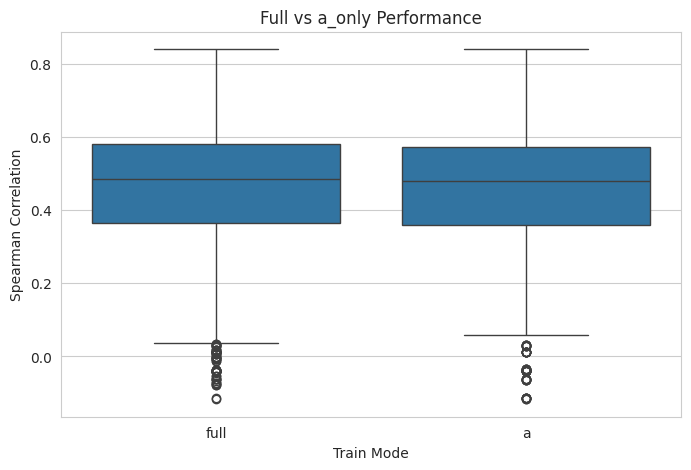

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=summary['train_mode'], y=summary['spearman'])
plt.title('Full vs a_only Performance')
plt.xlabel('Train Mode')
plt.ylabel('Spearman Correlation')
plt.show()

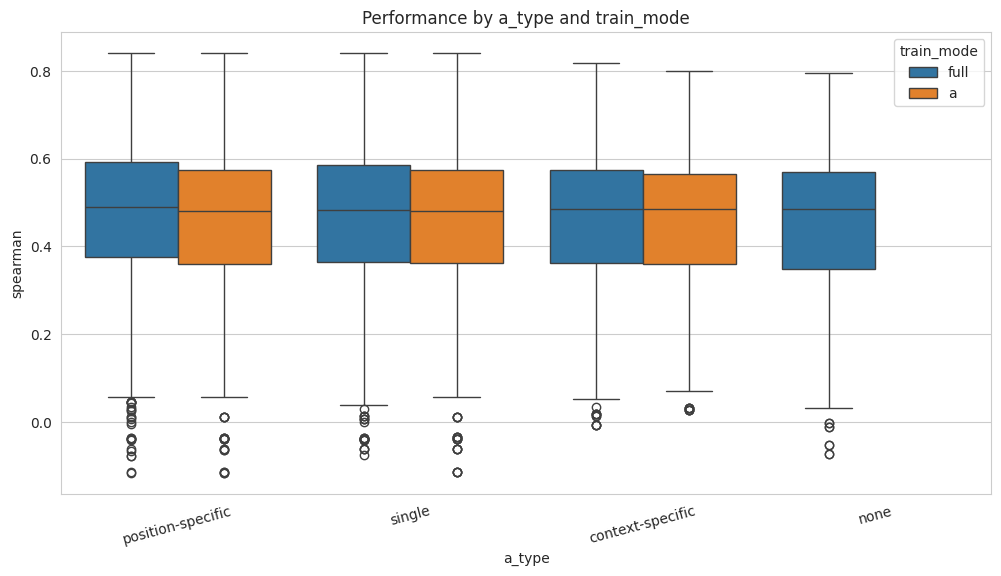

In [ ]:
plt.figure()
sns.boxplot(x=summary['a_type'], y=summary['spearman'], hue=summary['train_mode'])
plt.title('Performance by a_type and train_mode')
plt.xticks(rotation=15)
plt.show()

In [ ]:
temp_list = summary[(summary["a_type"]== "none") & (summary["spearman"] <= 0)]["dataset"].unique().tolist()

In [ ]:
summary[summary["dataset"].isin(temp_list)]

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
50,R1AB_SARS2_Flynn_2022,64,position-specific,-1.0,logits,full,0.398966,1146
51,R1AB_SARS2_Flynn_2022,96,position-specific,-1.0,logits,full,0.399098,1152
52,R1AB_SARS2_Flynn_2022,64,single,-1.0,scores,a,0.400985,1146
53,R1AB_SARS2_Flynn_2022,64,single,0.1,logits,full,-0.041314,1146
54,R1AB_SARS2_Flynn_2022,96,context-specific,-1.0,scores,a,0.284506,1146
...,...,...,...,...,...,...,...,...
3835,A0A140D2T1_ZIKV_Sourisseau_2019,64,single,0.1,logits,a,-0.062554,1920
3836,A0A140D2T1_ZIKV_Sourisseau_2019,64,context-specific,-1.0,logits,a,0.027360,1920
3837,A0A140D2T1_ZIKV_Sourisseau_2019,96,position-specific,-1.0,logits,a,0.145602,1920
3838,A0A140D2T1_ZIKV_Sourisseau_2019,96,context-specific,0.1,scores,a,0.030520,1920


In [ ]:
none_negative = summary[(summary['a_type'] == 'none') & (summary['spearman'] < 0)]['dataset'].unique()

context_positive = summary[(summary['a_type'] == 'context-specific') & (summary['spearman'] > 0)]['dataset'].unique()

matching_datasets = set(none_negative) & set(context_positive)

result = summary[(summary['dataset'].isin(matching_datasets)) & 
                 (summary['a_type'].isin(['none', 'context-specific']))]

result = result.sort_values(['dataset', 'a_type'])

print(f"Found {len(matching_datasets)} matching datasets: {matching_datasets}")
result

Found 3 matching datasets: {'POLG_DEN26_Suphatrakul_2023', 'A4D664_9INFA_Soh_2019', 'A0A140D2T1_ZIKV_Sourisseau_2019'}


,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,num_mutations
1955,A0A140D2T1_ZIKV_Sourisseau_2019,96,context-specific,-1.0,scores,a,0.030520,1920
1956,A0A140D2T1_ZIKV_Sourisseau_2019,96,context-specific,0.1,logits,full,0.017525,1920
1960,A0A140D2T1_ZIKV_Sourisseau_2019,96,context-specific,-1.0,logits,a,0.027360,1920
1963,A0A140D2T1_ZIKV_Sourisseau_2019,96,context-specific,-1.0,logits,full,0.017525,1920
1965,A0A140D2T1_ZIKV_Sourisseau_2019,64,context-specific,-1.0,scores,a,0.030520,1920
1967,A0A140D2T1_ZIKV_Sourisseau_2019,96,context-specific,0.1,scores,full,0.012978,1920
1972,A0A140D2T1_ZIKV_Sourisseau_2019,96,context-specific,0.1,logits,a,0.027360,1920
1977,A0A140D2T1_ZIKV_Sourisseau_2019,96,context-specific,-1.0,scores,full,0.012978,1920
1979,A0A140D2T1_ZIKV_Sourisseau_2019,96,context-specific,0.1,scores,a,0.030520,1920
1958,A0A140D2T1_ZIKV_Sourisseau_2019,96,none,0.1,scores,full,-0.072318,1920


In [ ]:
result["spearman"].describe()

count    70.000000
mean      0.077532
std       0.136419
min      -0.252172
25%       0.020548
50%       0.109954
75%       0.145972
max       0.262316
Name: spearman, dtype: float64

In [ ]:
pivot = summary.pivot_table(
    index='dataset', 
    columns=['a_type', 'a_init', 'combined_way', 'train_mode'], 
    values='spearman'
)
pivot

a_type                              context-specific                      \
a_init                                          -1.0                       
combined_way                                  logits              scores   
train_mode                                         a      full         a   
dataset                                                                    
A0A140D2T1_ZIKV_Sourisseau_2019             0.035215  0.017525  0.029616   
A0A192B1T2_9HIV1_Haddox_2018                0.534647  0.531879  0.534778   
A0A1I9GEU1_NEIME_Kennouche_2019             0.078527  0.018069  0.078779   
A0A247D711_LISMN_Stadelmann_2021            0.379432  0.408763  0.380371   
A0A2Z5U3Z0_9INFA_Doud_2016                  0.574521  0.574486  0.573739   
...                                              ...       ...       ...   
TRPC_SACS2_Chan_2017                        0.616740  0.603000  0.616256   
TRPC_THEMA_Chan_2017                        0.547345  0.538308  0.546865   
UBC9_HUMAN_Weile_2017                       0.504595  0.492631  0.504580   
VKOR1_HUMAN_Chiasson_2020_abundance         0.589518  0.593827  0.592629   
VKOR1_HUMAN_Chiasson_2020_activity          0.388086  0.383450  0.388086   

a_type                                                                       \
a_init                                              0.1                       
combined_way                                     logits              scores   
train_mode                               full         a      full         a   
dataset                                                                       
A0A140D2T1_ZIKV_Sourisseau_2019      0.012978  0.035215  0.017525  0.029616   
A0A192B1T2_9HIV1_Haddox_2018         0.532033  0.534647  0.531879  0.534778   
A0A1I9GEU1_NEIME_Kennouche_2019      0.034181  0.078527  0.018069  0.078779   
A0A247D711_LISMN_Stadelmann_2021     0.409815  0.379432  0.408763  0.380371   
A0A2Z5U3Z0_9INFA_Doud_2016           0.574554  0.574521  0.574486  0.573739   
...                                       ...       ...       ...       ...   
TRPC_SACS2_Chan_2017                 0.602641  0.616740  0.603000  0.616256   
TRPC_THEMA_Chan_2017                 0.537860  0.547345  0.538308  0.546865   
UBC9_HUMAN_Weile_2017                0.492753  0.504595  0.492631  0.504580   
VKOR1_HUMAN_Chiasson_2020_abundance  0.594010  0.589518  0.593827  0.592629   
VKOR1_HUMAN_Chiasson_2020_activity   0.383290  0.388086  0.383450  0.388086   

a_type                                             none            ...  \
a_init                                             -1.0       0.1  ...   
combined_way                                     scores    scores  ...   
train_mode                               full      full      full  ...   
dataset                                                            ...   
A0A140D2T1_ZIKV_Sourisseau_2019      0.012978 -0.086885 -0.086885  ...   
A0A192B1T2_9HIV1_Haddox_2018         0.532033  0.506800  0.506800  ...   
A0A1I9GEU1_NEIME_Kennouche_2019      0.034181  0.023346  0.023346  ...   
A0A247D711_LISMN_Stadelmann_2021     0.409815  0.356316  0.356316  ...   
A0A2Z5U3Z0_9INFA_Doud_2016           0.574554  0.424557  0.424557  ...   
...                                       ...       ...       ...  ...   
TRPC_SACS2_Chan_2017                 0.602641  0.544506  0.544506  ...   
TRPC_THEMA_Chan_2017                 0.537860  0.601096  0.601096  ...   
UBC9_HUMAN_Weile_2017                0.492753  0.533620  0.533620  ...   
VKOR1_HUMAN_Chiasson_2020_abundance  0.594010  0.482265  0.482265  ...   
VKOR1_HUMAN_Chiasson_2020_activity   0.383290  0.333723  0.333723  ...   

a_type                              position-specific              single  \
a_init                                            0.1                -1.0   
combined_way                                   scores              logits   
train_mode                                          a      full         a   
dataset                  

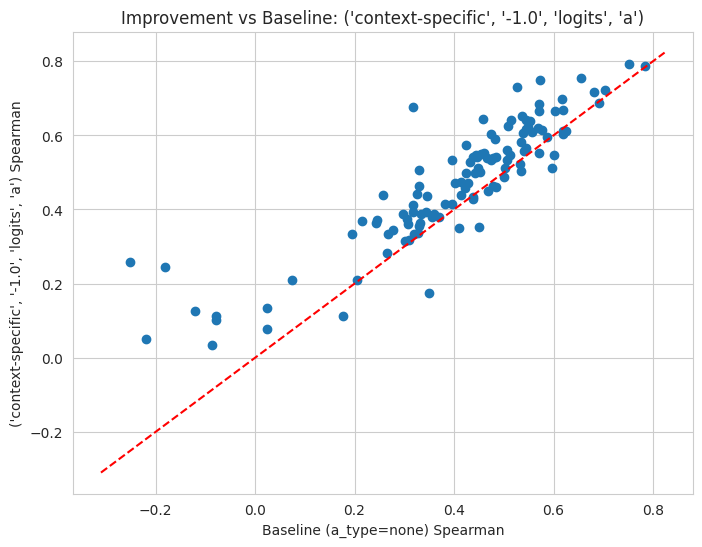

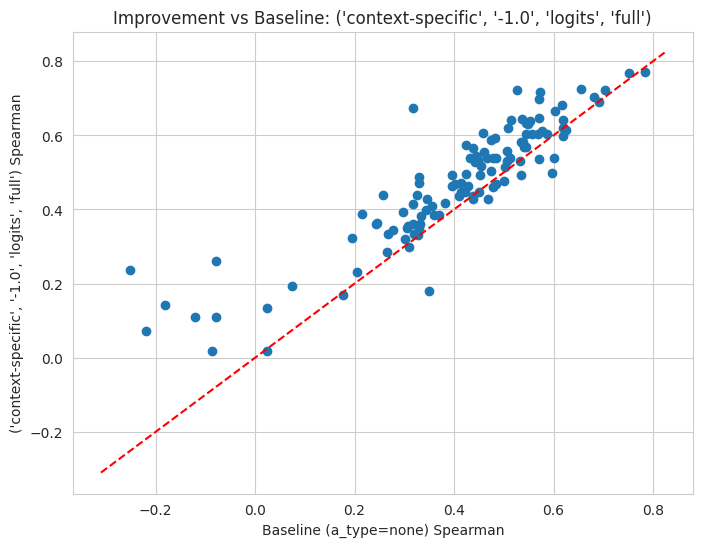

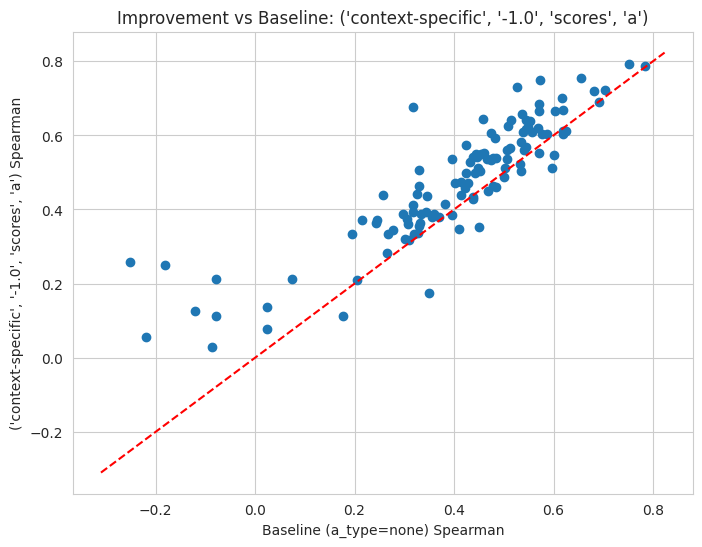

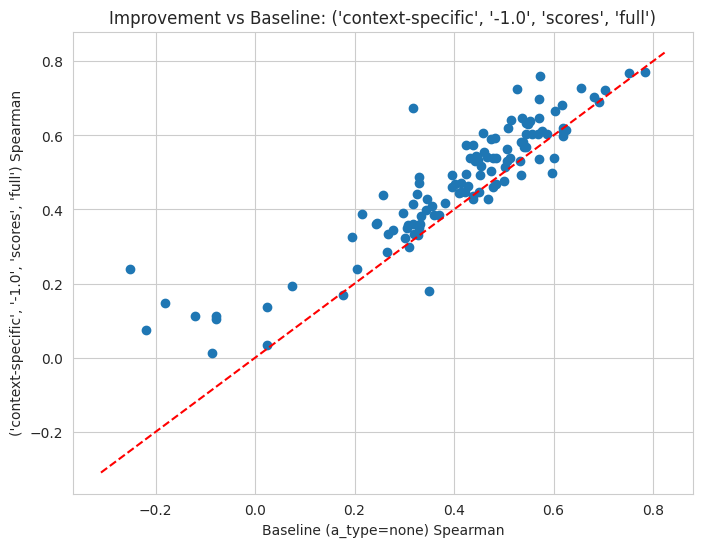

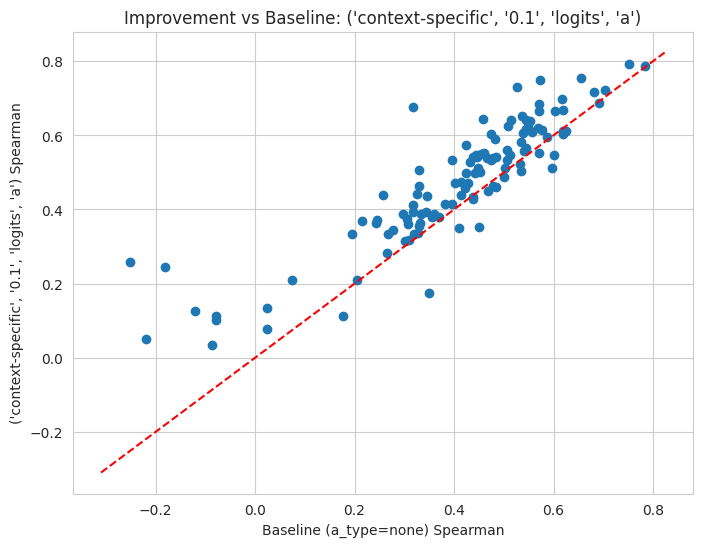

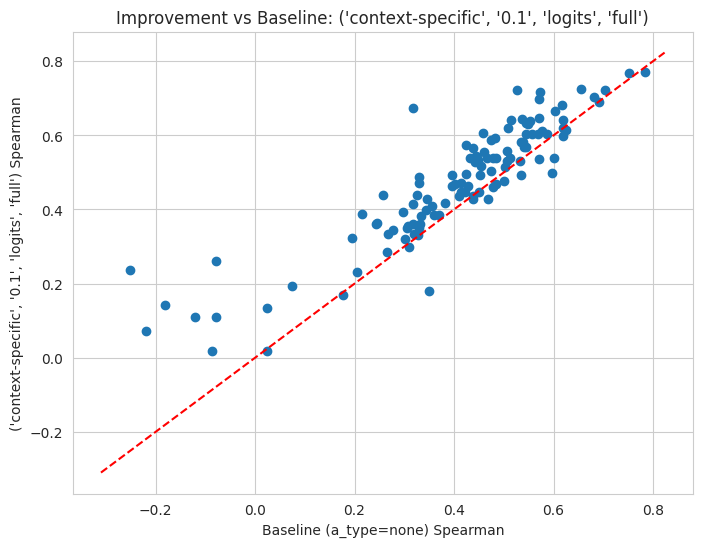

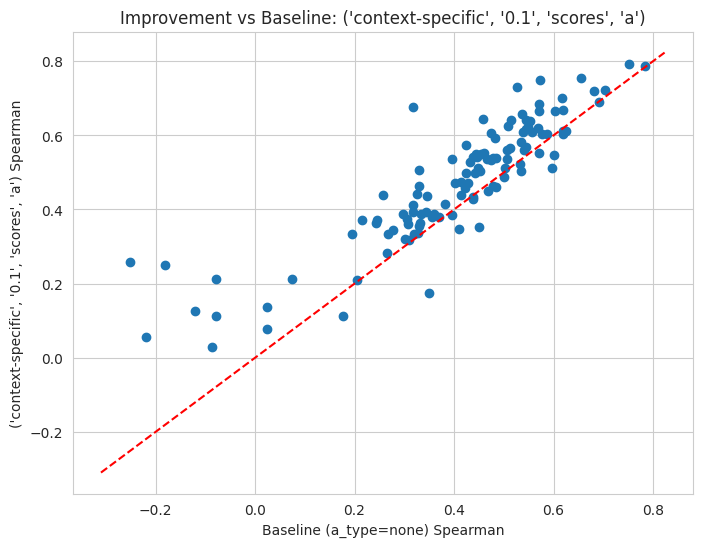

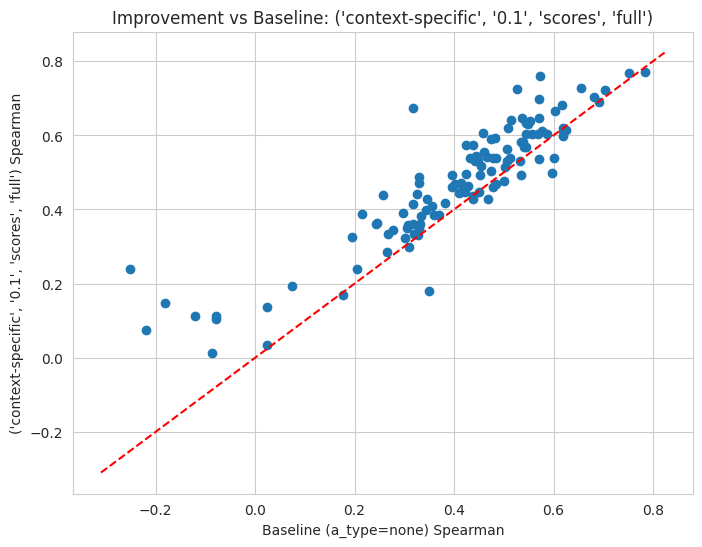

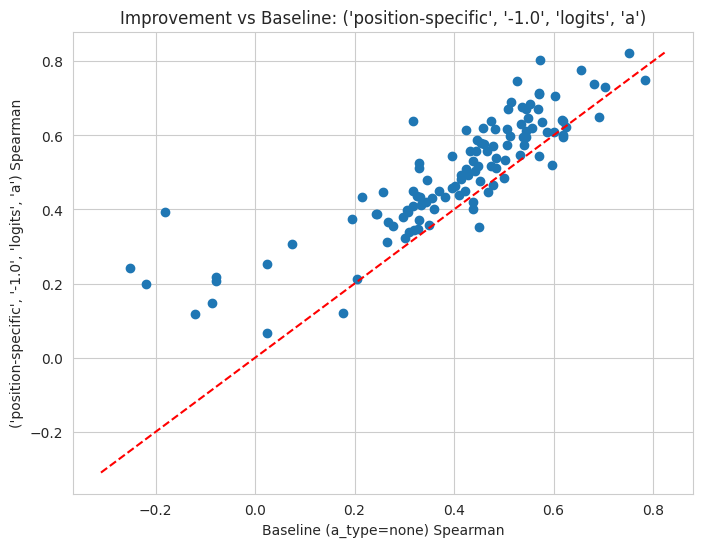

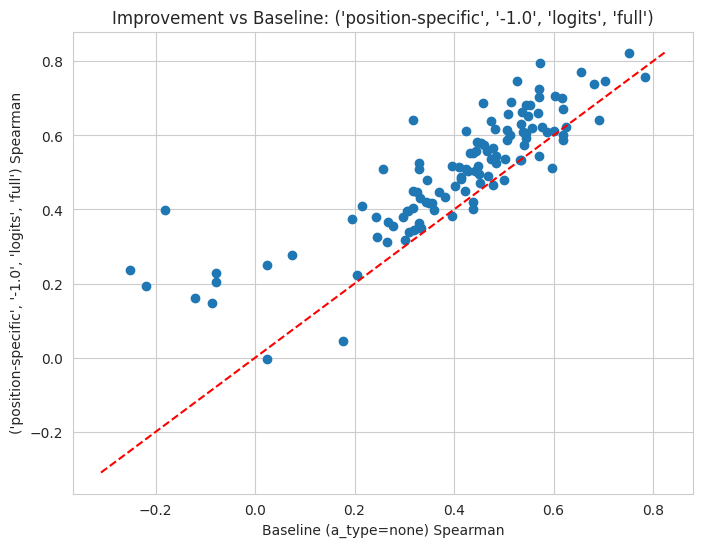

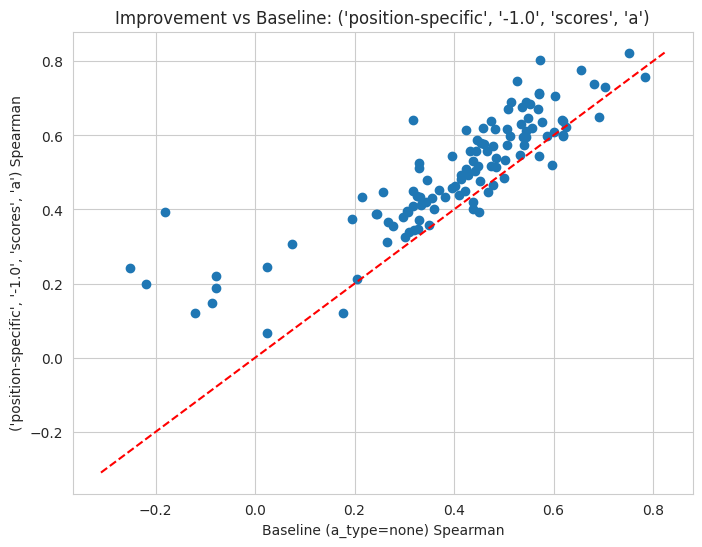

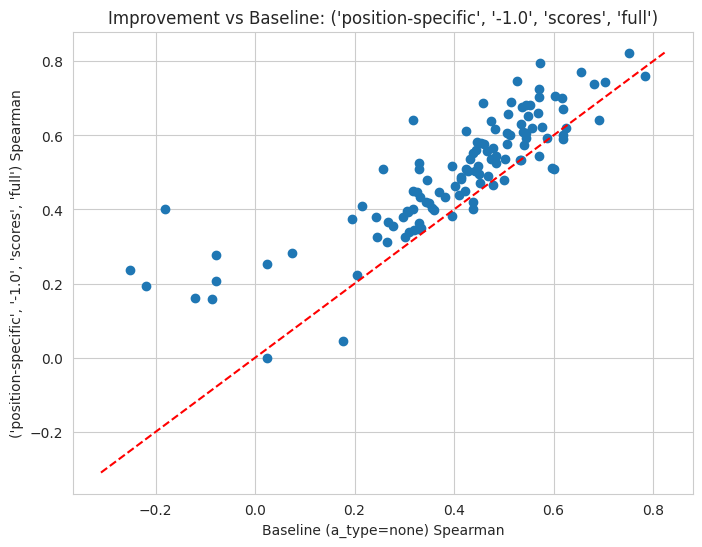

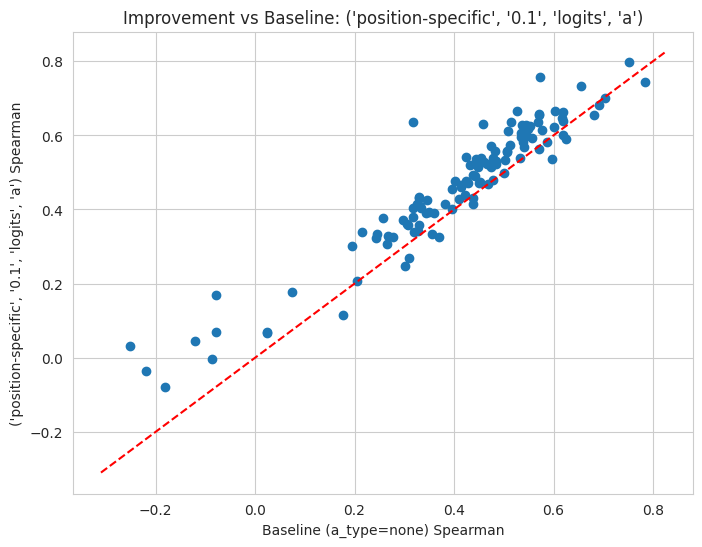

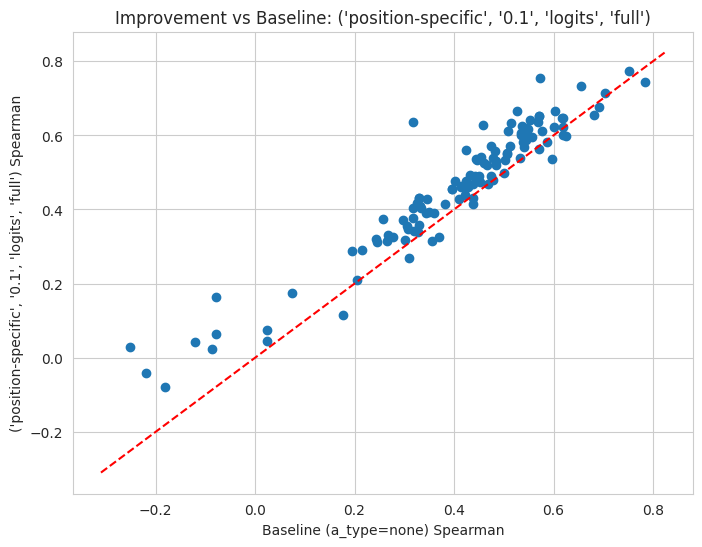

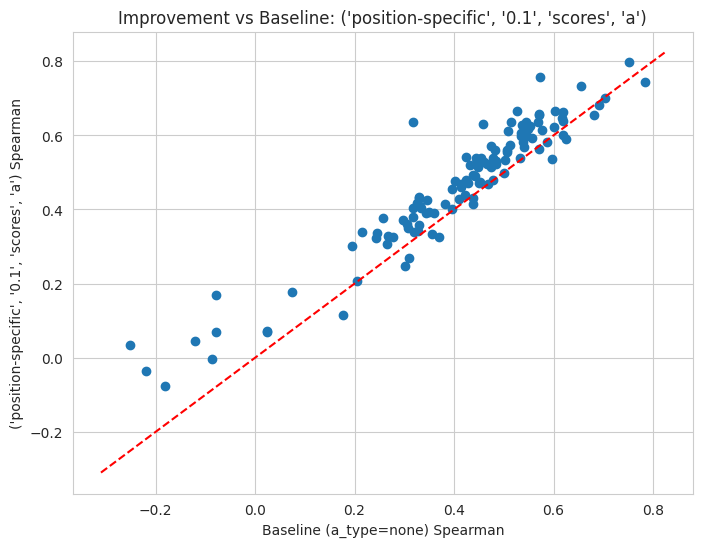

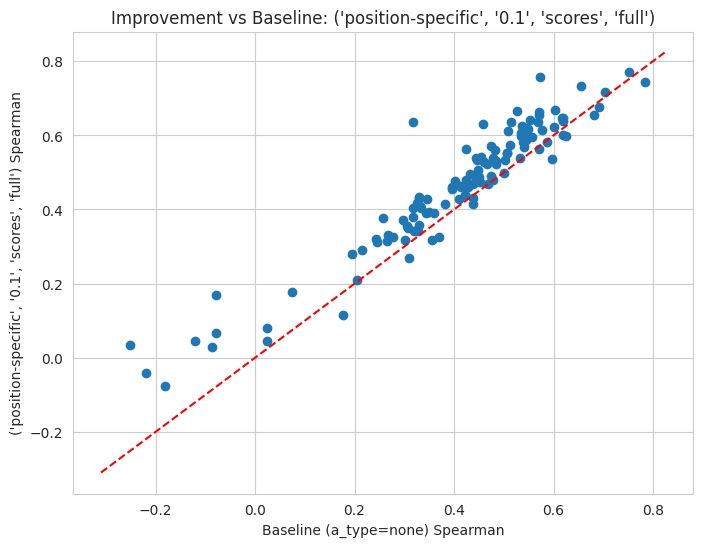

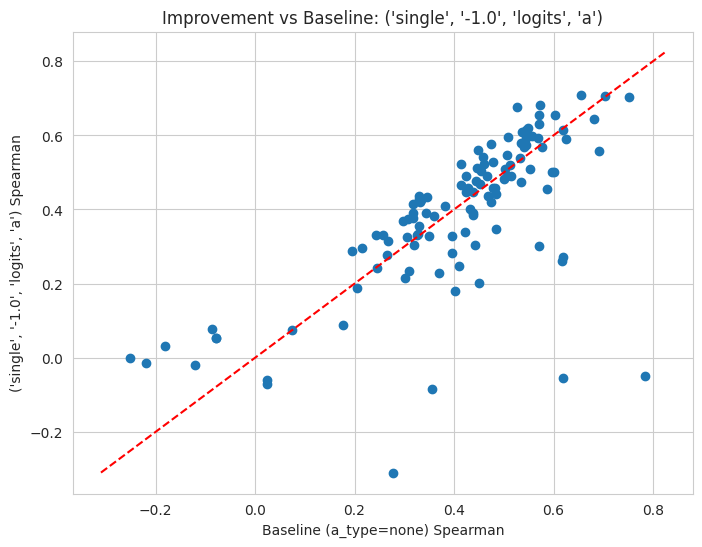

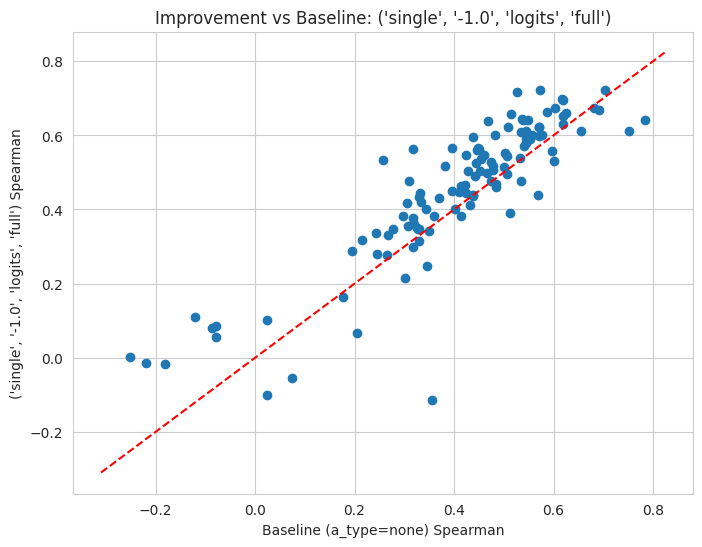

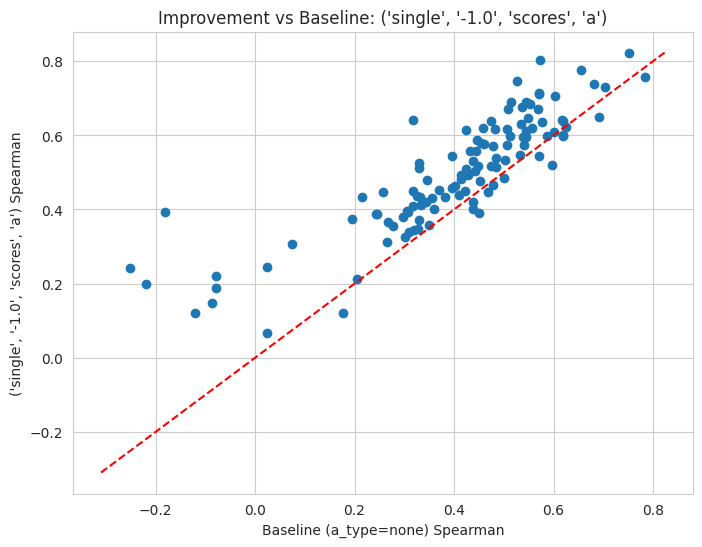

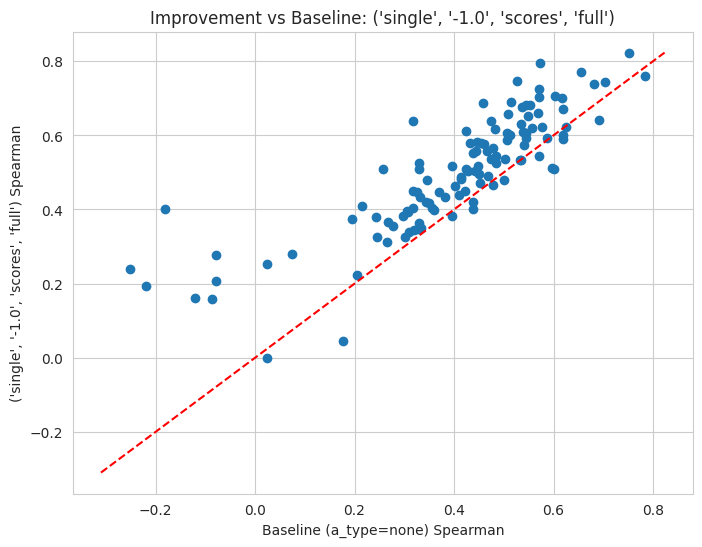

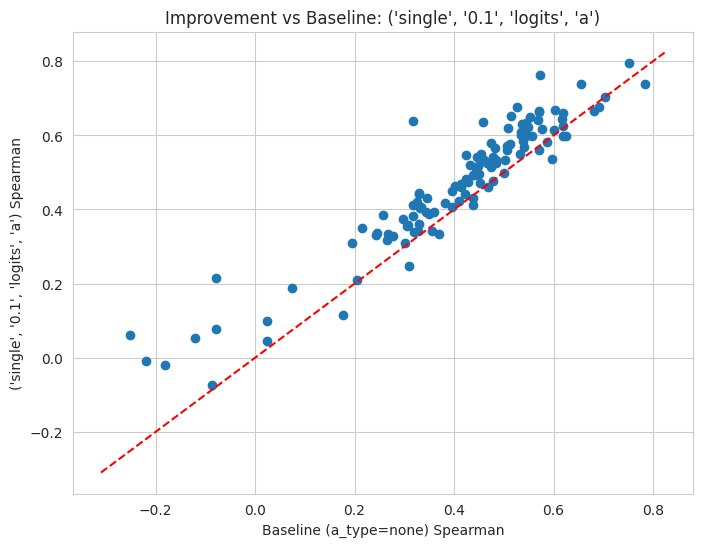

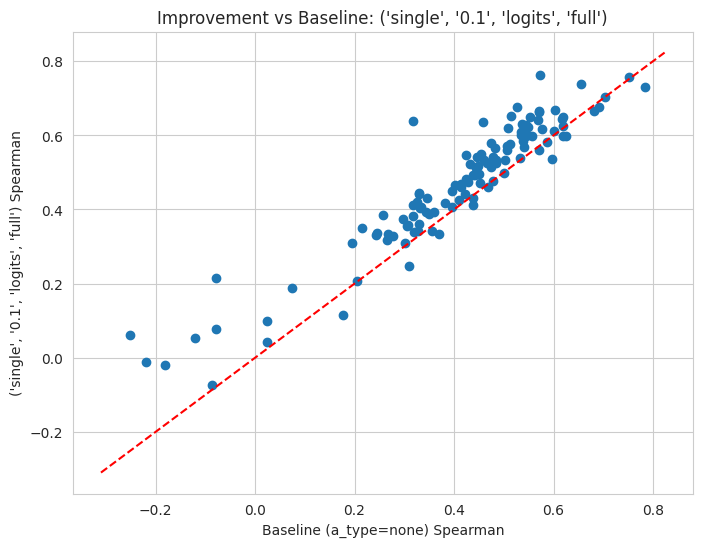

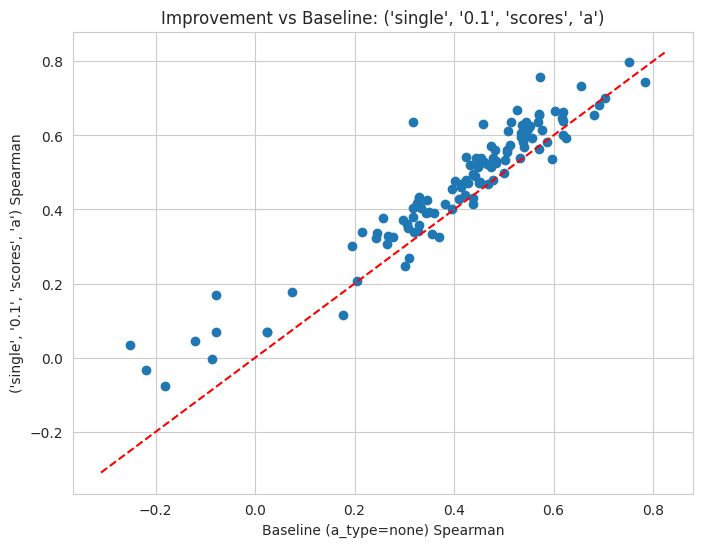

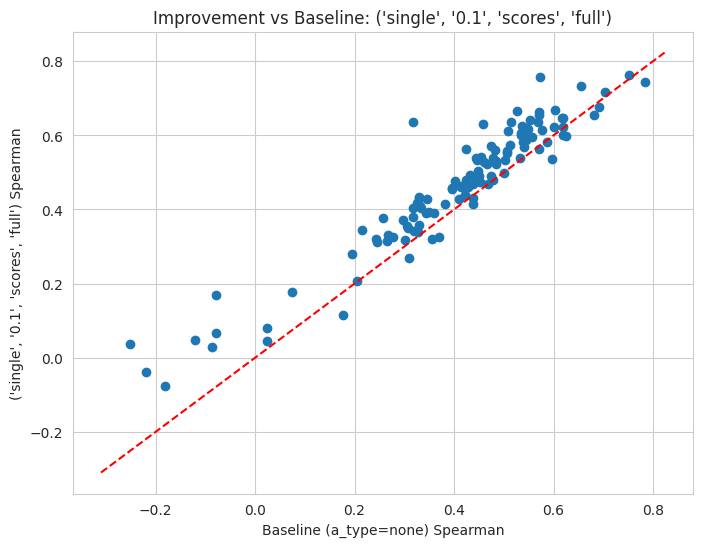

In [ ]:
for col in pivot.columns:
    if col[0] == 'none': continue  
    
    plt.figure(figsize=(8, 6))
    plt.scatter(pivot['none']["0.1"], pivot[col])
    plt.plot([pivot.min().min(), pivot.max().max()], 
             [pivot.min().min(), pivot.max().max()], 'r--') 
    
    plt.xlabel('Baseline (a_type=none) Spearman')
    plt.ylabel(f'{col} Spearman')
    plt.title(f'Improvement vs Baseline: {col}')
    plt.grid(True)
    plt.show()

In [ ]:
summary["train_mode"].unique()

array(['full', 'a'], dtype=object)

In [ ]:
summary[summary["train_mode"] == "None"]

,dataset,a_type,a_init,combined_way,train_mode,spearman,num_mutations


In [ ]:
summary[summary['a_type'] == 'None']['dataset']

Series([], Name: dataset, dtype: object)

In [ ]:
summary.head()

,dataset,a_type,a_init,combined_way,train_mode,spearman,num_mutations
0,GDIA_HUMAN_Silverstein_2021,position-specific,-1.0,scores,full,0.481679,232
1,GDIA_HUMAN_Silverstein_2021,context-specific,-1.0,scores,a,0.439743,232
2,GDIA_HUMAN_Silverstein_2021,single,0.1,logits,a,0.461730,232
3,GDIA_HUMAN_Silverstein_2021,position-specific,-1.0,scores,a,0.481679,232
4,GDIA_HUMAN_Silverstein_2021,single,-1.0,logits,a,0.465621,232


In [ ]:
neg1_df = summary[summary["a_init"] == "-1.0"]
pot1_df = summary[summary["a_init"] == "0.1"]

In [ ]:
grouped_dataset = summary.groupby("dataset")
for dataset, group0 in grouped_dataset:
    grouped_type = group0.groupby("a_type")
    for type, group1 in grouped_type:
        if len(group1) != 8:
            print(f"{dataset}{type} has more than 8")

A0A140D2T1_ZIKV_Sourisseau_2019none has more than 8
A0A192B1T2_9HIV1_Haddox_2018none has more than 8
A0A1I9GEU1_NEIME_Kennouche_2019none has more than 8
A0A247D711_LISMN_Stadelmann_2021none has more than 8
A0A2Z5U3Z0_9INFA_Doud_2016none has more than 8
A0A2Z5U3Z0_9INFA_Wu_2014none has more than 8
A4D664_9INFA_Soh_2019none has more than 8
A4GRB6_PSEAI_Chen_2020none has more than 8
AACC1_PSEAI_Dandage_2018none has more than 8
ACE2_HUMAN_Chan_2020none has more than 8
ADRB2_HUMAN_Jones_2020none has more than 8
AICDA_HUMAN_Gajula_2014_3cyclesnone has more than 8
AMIE_PSEAE_Wrenbeck_2017none has more than 8
ANCSZ_Hobbs_2022none has more than 8
B2L11_HUMAN_Dutta_2010_binding-Mcl-1none has more than 8
BLAT_ECOLX_Deng_2012none has more than 8
BLAT_ECOLX_Firnberg_2014none has more than 8
BLAT_ECOLX_Jacquier_2013none has more than 8
BLAT_ECOLX_Stiffler_2015none has more than 8
C6KNH7_9INFA_Lee_2018none has more than 8
CALM1_HUMAN_Weile_2017none has more than 8
CASP3_HUMAN_Roychowdhury_2020none ha

In [ ]:
none_df = summary[summary["a_type"] == "none"]
grouped_none = none_df.groupby("dataset")

for dataset, group in grouped_none:
    if len(group) != 2:
        print(f"{dataset} has more than 2 none")
    else:
        sr1, sr2 = group["spearman"].values
        if np.isclose(sr1, sr2):
            continue
        else:
            print(f"{dataset} unmatched non {sr1:.4f} vs {sr2:.4f}")

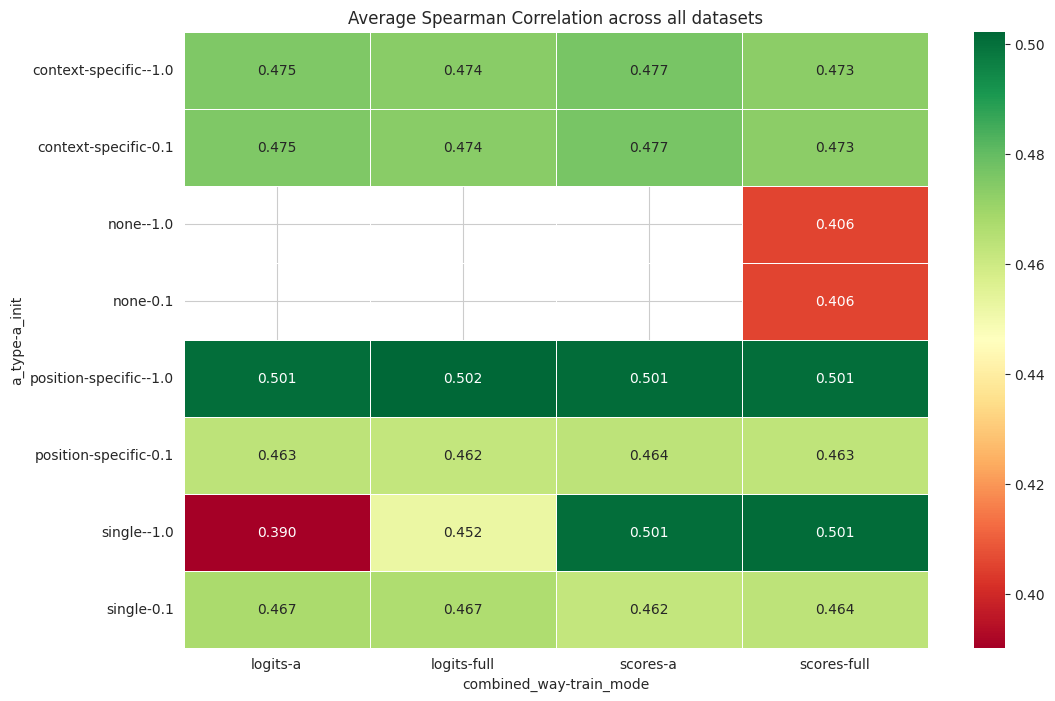

In [ ]:
pivot = summary.pivot_table(
    values='spearman',
    index=['a_type', 'a_init'],
    columns=['combined_way', 'train_mode'],
    aggfunc='mean'
).round(4)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='RdYlGn', fmt='.3f', linewidths=0.5)
plt.title('Average Spearman Correlation across all datasets')
plt.show()

In [ ]:
stats = summary.groupby(['a_type', 'a_init', 'combined_way', 'train_mode'])['spearman']\
               .agg(['mean', 'std', 'max', 'count'])\
               .round(4)\
               .sort_values('mean', ascending=False)

print("=== Average performance per configuration (sorted) ===")
display(stats)

=== Average performance per configuration (sorted) ===


mean     std     max  \
a_type            a_init combined_way train_mode                           
position-specific -1.0   logits       full        0.5023  0.1587  0.8231   
single            -1.0   scores       full        0.5014  0.1575  0.8226   
position-specific -1.0   scores       a           0.5012  0.1550  0.8226   
                                      full        0.5009  0.1573  0.8226   
                         logits       a           0.5008  0.1549  0.8226   
single            -1.0   scores       a           0.5007  0.1556  0.8226   
context-specific  0.1    scores       a           0.4767  0.1652  0.7935   
                  -1.0   scores       a           0.4767  0.1652  0.7935   
                  0.1    logits       a           0.4755  0.1669  0.7935   
                  -1.0   logits       a           0.4755  0.1669  0.7935   
                  0.1    logits       full        0.4738  0.1631  0.7706   
                  -1.0   logits       full        0.4738  0.1631  0.7706   
                  0.1    scores       full        0.4731  0.1652  0.7706   
                  -1.0   scores       full        0.4731  0.1652  0.7706   
single            0.1    logits       a           0.4673  0.1768  0.7948   
                                      full        0.4667  0.1761  0.7619   
                         scores       full        0.4635  0.1773  0.7629   
position-specific 0.1    scores       a           0.4635  0.1787  0.7965   
                         logits       a           0.4634  0.1787  0.7965   
                         scores       full        0.4631  0.1781  0.7719   
single            0.1    scores       a           0.4622  0.1788  0.7965   
position-specific 0.1    logits       full        0.4621  0.1781  0.7745   
single            -1.0   logits       full        0.4522  0.1915  0.7226   
none              -1.0   scores       full        0.4056  0.1977  0.7832   
                  0.1    scores       full        0.4056  0.1977  0.7832   
single            -1.0   logits       a           0.3903  0.2035  0.7085   

                                                  count  
a_type            a_init combined_way train_mode         
position-specific -1.0   logits       full          116  
single            -1.0   scores       full          116  
position-specific -1.0   scores       a             115  
                                      full          116  
                         logits       a             115  
single            -1.0   scores       a             114  
context-specific  0.1    scores       a             116  
                  -1.0   scores       a             116  
                  0.1    logits       a             116  
                  -1.0   logits       a             116  
                  0.1    logits       full          116  
                  -1.0   logits       full          116  
                  0.1    scores       full          116  
                  -1.0   scores       full          116  
single            0.1    logits       a             116  
                                      full          116  
                         scores       full          116  
position-specific 0.1    scores       a             116  
                         logits       a             116  
                         scores       full          116  
single            0.1    scores       a             115  
position-specific 0.1    logits       full          116  
single            -1.0   logits       full          116  
none              -1.0   scores       full          116  
                  0.1    scores       full          116  
single            -1.0   logits       a             116

In [ ]:
baseline = (summary[summary['a_type'] == 'none']
            .groupby('dataset')['spearman']
            .mean()  
            .rename('none_sr'))

non_none = summary[summary['a_type'] != 'none']
best_other = (non_none.groupby('dataset')['spearman']
              .max()
              .rename('best_other_sr'))

In [ ]:
baseline

dataset
A0A1I9GEU1_NEIME_Kennouche_2019         0.023346
A0A247D711_LISMN_Stadelmann_2021        0.356316
A4GRB6_PSEAI_Chen_2020                  0.527284
AACC1_PSEAI_Dandage_2018                0.477571
AICDA_HUMAN_Gajula_2014_3cycles         0.349479
AMIE_PSEAE_Wrenbeck_2017                0.568856
B2L11_HUMAN_Dutta_2010_binding-Mcl-1    0.783180
BLAT_ECOLX_Deng_2012                    0.454633
BLAT_ECOLX_Firnberg_2014                0.573538
BLAT_ECOLX_Jacquier_2013                0.655040
BLAT_ECOLX_Stiffler_2015                0.680856
CALM1_HUMAN_Weile_2017                  0.204655
CASP3_HUMAN_Roychowdhury_2020           0.538014
CASP7_HUMAN_Roychowdhury_2020           0.534763
CCDB_ECOLI_Adkar_2012                   0.257643
CCDB_ECOLI_Tripathi_2016                0.296571
CCR5_HUMAN_Gill_2023                    0.329688
DYR_ECOLI_Nguyen_2023                   0.503177
DYR_ECOLI_Thompson_2019                 0.473295
ENVZ_ECOLI_Ghose_2023                   0.301170
ESTA_BACSU_N

In [ ]:
best_other

dataset
A0A1I9GEU1_NEIME_Kennouche_2019         0.078779
A0A247D711_LISMN_Stadelmann_2021        0.429958
A4GRB6_PSEAI_Chen_2020                  0.747493
AACC1_PSEAI_Dandage_2018                0.572305
AICDA_HUMAN_Gajula_2014_3cycles         0.417680
AMIE_PSEAE_Wrenbeck_2017                0.672160
B2L11_HUMAN_Dutta_2010_binding-Mcl-1    0.787498
BLAT_ECOLX_Deng_2012                    0.579806
BLAT_ECOLX_Firnberg_2014                0.802468
BLAT_ECOLX_Jacquier_2013                0.776644
BLAT_ECOLX_Stiffler_2015                0.739143
CALM1_HUMAN_Weile_2017                  0.239388
CASP3_HUMAN_Roychowdhury_2020           0.641851
CASP7_HUMAN_Roychowdhury_2020           0.630791
CCDB_ECOLI_Adkar_2012                   0.533718
CCDB_ECOLI_Tripathi_2016                0.391842
CCR5_HUMAN_Gill_2023                    0.372025
DYR_ECOLI_Nguyen_2023                   0.551787
DYR_ECOLI_Thompson_2019                 0.536460
ENVZ_ECOLI_Ghose_2023                   0.326782
ESTA_BACSU_N

In [ ]:
comparison = pd.concat([baseline, best_other], axis=1).reset_index()

comparison['absolute_gain']     = comparison['best_other_sr'] - comparison['none_sr']
comparison['percentage_gain_%'] = ((comparison['absolute_gain'] / comparison['none_sr']) * 100).round(2)

In [ ]:
comparison = comparison.sort_values('percentage_gain_%', ascending=False).reset_index(drop=True)

In [ ]:
display(comparison[['dataset', 'none_sr', 'best_other_sr', 
                    'absolute_gain', 'percentage_gain_%']])

,dataset,none_sr,best_other_sr,absolute_gain,percentage_gain_%
0,A0A1I9GEU1_NEIME_Kennouche_2019,0.023346,0.078779,0.055433,237.45
1,GLPA_HUMAN_Elazar_2016,0.317608,0.676614,0.359006,113.03
2,CCDB_ECOLI_Adkar_2012,0.257643,0.533718,0.276075,107.15
3,ESTA_BACSU_Nutschel_2020,0.214124,0.433996,0.219872,102.68
4,REV_HV1H2_Fernandes_2016,0.246110,0.387667,0.141557,57.52
5,NUD15_HUMAN_Suiter_2020,0.458757,0.686133,0.227377,49.56
6,A4GRB6_PSEAI_Chen_2020,0.527284,0.747493,0.220209,41.76
7,BLAT_ECOLX_Firnberg_2014,0.573538,0.802468,0.228930,39.92
8,RPC1_LAMBD_Li_2019_low-expression,0.437534,0.594462,0.156928,35.87
9,RASH_HUMAN_Bandaru_2017,0.431237,0.578975,0.147737,34.26


In [ ]:
summary[summary["dataset"] == "R1AB_SARS2_Flynn_2022"]

,dataset,a_type,a_init,combined_way,train_mode,spearman,num_mutations
0,R1AB_SARS2_Flynn_2022,position-specific,-1.0,scores,full,0.400838,1152
1,R1AB_SARS2_Flynn_2022,context-specific,-1.0,scores,a,0.250516,1152
2,R1AB_SARS2_Flynn_2022,single,0.1,logits,a,-0.020870,1152
3,R1AB_SARS2_Flynn_2022,position-specific,-1.0,scores,a,0.393115,1152
4,R1AB_SARS2_Flynn_2022,single,-1.0,logits,a,0.030712,1152
5,R1AB_SARS2_Flynn_2022,none,0.1,scores,full,-0.181322,1152
6,R1AB_SARS2_Flynn_2022,position-specific,0.1,logits,full,-0.078525,1152
7,R1AB_SARS2_Flynn_2022,context-specific,0.1,logits,full,0.142501,1152
8,R1AB_SARS2_Flynn_2022,context-specific,0.1,logits,a,0.246110,1152
9,R1AB_SARS2_Flynn_2022,position-specific,0.1,scores,full,-0.077242,1152


In [ ]:
# method specific check
single_summary =